# Enhanced Earnings IV Analysis - Meeting Requirements

This notebook demonstrates the enhanced analysis functions based on the meeting discussion:

## Key Features:
1. **Realized Volatility Estimators** - Multiple rolling/exponentially weighted estimators
2. **Volume Analysis** - Option volume vs stock ADV analysis
3. **Kernel Regression** - Enhanced regression from Wolfe paper approach
4. **Single-Name Case Studies** - Comprehensive analysis for individual stocks
5. **Large Cap Universe** - Building filtered universe of liquid stocks

## Meeting Requirements Addressed:
- ✅ Kernel regression interface
- ✅ Realized volatility computation with multiple estimators
- ✅ Volume analysis (option notional vs stock ADV)
- ✅ Single-name vs cross-sectional approach
- ✅ Robust regression model with proper X and y variables
- ✅ Large cap universe with option volume filters

In [107]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wrds
import warnings
warnings.filterwarnings('ignore')

# Import the enhanced analysis functions
from enhanced_analysis import (
    calculate_realized_volatility_estimators,
    analyze_option_volume_vs_stock_adv,
    enhanced_kernel_regression_analysis,
    build_regression_dataset,
    run_single_name_case_study,
    get_large_cap_universe
)

In [7]:
from datetime import datetime, timedelta
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [109]:
class EarningsIVDataPipeline:
    """
    Enhanced data pipeline for earnings implied volatility analysis using WRDS data
    """
    
    def __init__(self, db_connection):
        """
        Initialize with existing WRDS connection
        
        Args:
            db_connection: Existing WRDS database connection
        """
        self.db = db_connection
        self.data = {}
        self.available_tables = None
        
    def setup_optionm_tables(self):
        """
        Get available OptionMetrics tables
        """
        if self.available_tables is None:
            tables_df = self.db.raw_sql("""
                SELECT table_name
                FROM information_schema.tables
                WHERE table_schema = 'optionm'
                ORDER BY table_name
            """)
            self.available_tables = set(tables_df['table_name'].str.lower())
        return self.available_tables
    
    def build_optionm_query(self, table_base, start_date, end_date, fields, secids=None):
        """
        Build OptionMetrics query using your existing query builder logic
        """
        table_base = table_base.lower()
        
        # Match all tables starting with the given base (e.g. opprcd)
        matching_tables = [t for t in self.available_tables if t.startswith(table_base)]
        if not matching_tables:
            return f"Table '{table_base}' not found in OptionMetrics."
        
        # SECID filter
        secid_filter = ""
        if secids is not None:
            if isinstance(secids, (list, tuple, set)):
                secid_list = ", ".join(str(s) for s in secids)
                secid_filter = f"AND secid IN ({secid_list})"
            else:
                secid_filter = f"AND secid = {secids}"
        
        # Determine year range
        years = list(range(pd.to_datetime(start_date).year, pd.to_datetime(end_date).year + 1))
        
        # Case: non-suffixed (single) table (e.g., 'securd1')
        if table_base in matching_tables:
            return f"""
    SELECT {', '.join(fields)}
    FROM optionm.{table_base}
    WHERE date BETWEEN '{start_date}' AND '{end_date}'
    {secid_filter}
            """.strip()
        
        # Case: year-suffixed tables (e.g., opprcd2014, hvold2015, etc.)
        union_queries = []
        for year in years:
            table_year = f"{table_base}{year}"
            if table_year in matching_tables:
                query = f"""
    SELECT {', '.join(fields)}
    FROM optionm.{table_year}
    WHERE date BETWEEN '{start_date}' AND '{end_date}'
    {secid_filter}
    """.strip()
                union_queries.append(query)
        
        if not union_queries:
            return f"No available year-specific tables for '{table_base}' in range {years}."
        
        return "\nUNION ALL\n".join(union_queries)
    
    def build_rdq_query_from_tickers(self, ticker_list, start_date, end_date):
        """
        Build SQL query to fetch earnings report dates (rdq) for a list of tickers.
        """
        if not ticker_list:
            raise ValueError("You must provide at least one ticker.")
        
        # Format tickers for SQL IN clause
        formatted_tickers = ', '.join([f"'{ticker}'" for ticker in ticker_list])
        
        query = f"""
        SELECT cusip,
               tic as ticker,
               datadate,
               rdq as earnings_date,
               fyearq,
               fqtr
        FROM comp.fundq
        WHERE tic IN ({formatted_tickers})
          AND rdq BETWEEN '{start_date}' AND '{end_date}'
          AND rdq IS NOT NULL
        ORDER BY tic, rdq;
        """
        return query
    
    def build_secprd_query(self, secid_list, start_date, end_date):
        """
        Build SQL query to fetch daily stock data from optionm.secprd for a list of SECIDs.
        """
        if not secid_list:
            raise ValueError("SECID list is empty.")
        
        # Format SECIDs as numeric values, no quotes
        formatted_secids = ', '.join([str(int(secid)) for secid in secid_list])
        
        query = f"""
        SELECT *
        FROM optionm.secprd
        WHERE secid IN ({formatted_secids})
          AND date BETWEEN '{start_date}' AND '{end_date}'
        ORDER BY secid, date;
        """
        return query
    
    def get_securities_info(self, ticker_list):
        """
        Get security information from OptionMetrics securd1 table
        """
        print("Fetching security information from OptionMetrics...")
        
        # Format tickers for SQL IN clause
        formatted_tickers = ', '.join([f"'{ticker}'" for ticker in ticker_list])
        
        query = f"""
        SELECT DISTINCT *
        FROM optionm.securd1
        WHERE ticker IN ({formatted_tickers})
          AND exchange_d != 0
        ORDER BY ticker
        """
        
        self.data['securities'] = self.db.raw_sql(query)
        print(f"Retrieved {len(self.data['securities'])} securities")
        
        return self.data['securities']
    
    def get_earnings_dates(self, ticker_list, start_date='2023-01-01', end_date='2024-12-31'):
        """
        Fetch earnings announcement dates using Compustat
        """
        print("Fetching earnings announcement dates from Compustat...")
        
        query = self.build_rdq_query_from_tickers(ticker_list, start_date, end_date)
        
        try:
            self.data['earnings'] = self.db.raw_sql(query)
            print(f"Retrieved {len(self.data['earnings'])} earnings announcements")
            return self.data['earnings']
        except Exception as e:
            print(f"Error fetching earnings data: {e}")
            return None
    
    def get_option_data(self, secid_list, start_date='2023-01-01', end_date='2024-12-31'):
        """
        Fetch option data from OptionMetrics using secids - NO SYNTHETIC DATA
        """
        print("Fetching option data from OptionMetrics...")
        
        # Setup available tables
        self.setup_optionm_tables()
        
        # Define fields to select - using common OptionMetrics field names
        fields = [
            'date', 'secid', 'exdate', 'strike_price', 'cp_flag',
            'best_bid', 'best_offer', 'open_interest',
            'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume'
        ]
        
        # Build query using your query builder
        query = self.build_optionm_query('opprcd', start_date, end_date, fields, secid_list)
        
        if "not found" in query or "No available" in query:
            print(f"Query build failed: {query}")
            return None
        
        try:
            print("Executing options query...")
            self.data['options'] = self.db.raw_sql(query)
            
            # Debug: Print column names to see what's available
            print(f"Available columns in options data: {list(self.data['options'].columns)}")
            
            # Check for volume column variations
            volume_field_candidates = ['volume', 'vol', 'contract_volume', 'opt_volume']
            volume_col = None
            for col_candidate in volume_field_candidates:
                if col_candidate in self.data['options'].columns:
                    volume_col = col_candidate
                    break
            
            if volume_col and volume_col != 'volume':
                print(f"Found volume column: {volume_col}, renaming to 'volume'")
                self.data['options']['volume'] = self.data['options'][volume_col]
            
            print(f"Retrieved {len(self.data['options'])} option records")
            return self.data['options']
            
        except Exception as e:
            print(f"Error fetching options data: {e}")
            print("Attempting to query with minimal fields...")
            
            # Fallback: try with minimal fields - NO SYNTHETIC DATA
            minimal_fields = ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 
                            'best_bid', 'best_offer', 'impl_volatility']
            
            query = self.build_optionm_query('opprcd', start_date, end_date, minimal_fields, secid_list)
            
            try:
                self.data['options'] = self.db.raw_sql(query)
                print(f"Retrieved {len(self.data['options'])} option records with minimal fields")
                print("Warning: Limited fields available - some analyses may not be possible")
                return self.data['options']
            except Exception as e2:
                print(f"Fallback also failed: {e2}")
                return None
    
    def get_stock_prices(self, secid_list, start_date='2023-01-01', end_date='2024-12-31'):
        """
        Get underlying stock prices from OptionMetrics secprd
        """
        print("Fetching stock prices from OptionMetrics...")
        
        query = self.build_secprd_query(secid_list, start_date, end_date)
        
        try:
            self.data['stock_prices'] = self.db.raw_sql(query)
            print(f"Retrieved {len(self.data['stock_prices'])} stock price records")
            return self.data['stock_prices']
        except Exception as e:
            print(f"Error fetching stock prices: {e}")
            return None
    
    def merge_securities_earnings(self):
        """
        Merge securities info with earnings data using ticker matching
        """
        if 'securities' not in self.data or 'earnings' not in self.data:
            print("Need both securities and earnings data")
            return None
        
        # Merge on ticker
        merged = self.data['earnings'].merge(
            self.data['securities'][['secid', 'ticker', 'cusip', 'issuer']], 
            on='ticker', 
            how='inner'
        )
        
        self.data['earnings_securities'] = merged
        print(f"Merged {len(merged)} earnings-securities records")
        return merged
    
    def calculate_option_metrics(self):
        """
        Calculate additional option metrics - ONLY WITH REAL DATA
        """
        if 'options' not in self.data:
            raise ValueError("Options data not loaded. Run get_option_data() first.")
        
        df = self.data['options'].copy()

        # Convert strike price to original form
        df['strike_price']=df['strike_price']/1000
        
        # Convert dates to datetime objects
        df['date'] = pd.to_datetime(df['date'])
        df['exdate'] = pd.to_datetime(df['exdate'])
        
        # Calculate time to expiration in days
        df['tte'] = (df['exdate'] - df['date']).dt.days
        
        # Initialize underlying_price columns
        df['underlying_price'] = np.nan

        # Merge with stock prices to get underlying prices
        if 'stock_prices' in self.data and not self.data['stock_prices'].empty:
            stock_df = self.data['stock_prices'].copy()
            stock_df['date'] = pd.to_datetime(stock_df['date'])
            
            # Rename columns in stock_df BEFORE merging to avoid suffix issues
            stock_df = stock_df.rename(columns={'close': 'underlying_price'})
            
            # Only merge if stock_df has the necessary columns after rename
            if 'underlying_price' in stock_df.columns:
                df = df.merge(stock_df[['date', 'secid', 'underlying_price']], 
                              on=['date', 'secid'], 
                              how='left',
                              suffixes=('', '_stock')) 
            else:
                print("Warning: stock_prices DataFrame is missing 'close' column. Cannot merge underlying price.")
        else:
            print("Warning: No stock prices data available. Cannot calculate proper moneyness.")
            
        # Calculate mid_price
        if 'best_bid' in df.columns and 'best_offer' in df.columns:
            df['mid_price'] = (df['best_bid'] + df['best_offer']) / 2
        
        # Only fill missing underlying prices with mid_price if both exist
        if 'mid_price' in df.columns:
            df['underlying_price'] = df['underlying_price'].fillna(df['mid_price'])

        # Calculate moneyness: Keep your original calculation
        df['moneyness'] = df['underlying_price_stock']/df['strike_price']
        
        # Calculate bid-ask spread only if both bid and offer exist
        if 'best_bid' in df.columns and 'best_offer' in df.columns:
            df['bid_ask_spread'] = np.where(
                df['best_bid'] > 0, 
                (df['best_offer'] - df['best_bid']) / df['best_bid'], 
                np.nan 
            )
            df['bid_ask_spread'] = df['bid_ask_spread'].clip(lower=0) 
        
        # Log moneyness - only if moneyness is valid
        if 'moneyness' in df.columns:
            df['log_moneyness'] = np.log(df['moneyness'].clip(lower=0.01)) 
        
        self.data['options_enhanced'] = df
        print(f"Enhanced {len(df)} option records with calculated metrics")
        
        return df
    
    def apply_data_filters(self, min_volume=3, max_bid_ask_spread=0.5, 
                           tte_range=(7, 60), moneyness_range=(0.8, 1.2)):
        """
        Apply data quality filters - ONLY filter on available real data
        """
        if 'options_enhanced' not in self.data:
            self.calculate_option_metrics()
        
        df = self.data['options_enhanced'].copy()
        initial_count = len(df)
        
        print(f"Applying filters to {initial_count:,} records...")
        print(f"Available columns: {list(df.columns)}")
        
        # Apply filters conditionally based on available columns
        
        if 'volume' in df.columns:
            df_before = len(df)
            df = df[df['volume'].notna() & (df['volume'] >= min_volume)]
            print(f"  After Volume filter (>= {min_volume}): {len(df):,} records ({len(df)/df_before:.1%} retained)")
        
        if 'bid_ask_spread' in df.columns:
            df_before = len(df)
            df = df[df['bid_ask_spread'].notna() & (df['bid_ask_spread'] <= max_bid_ask_spread)]
            print(f"  After Bid-ask spread filter (<= {max_bid_ask_spread}): {len(df):,} records ({len(df)/df_before:.1%} retained)")
        
        if 'tte' in df.columns:
            df_before = len(df)
            df = df[(df['tte'] >= tte_range[0]) & (df['tte'] <= tte_range[1])]
            print(f"  After TTE filter ({tte_range[0]} <= tte <= {tte_range[1]}): {len(df):,} records ({len(df)/df_before:.1%} retained)")
        
        if 'moneyness' in df.columns:
            df_before = len(df)
            df = df[(df['moneyness'] >= moneyness_range[0]) & (df['moneyness'] <= moneyness_range[1])]
            print(f"  After Moneyness filter ({moneyness_range[0]} <= moneyness <= {moneyness_range[1]}): {len(df):,} records ({len(df)/df_before:.1%} retained)")
        
        # Only filter on real data columns
        real_data_filters = [
            ('vega', lambda x: x > 0),
            ('best_bid', lambda x: x > 0),
            ('best_offer', lambda x: x > 0),
            ('impl_volatility', lambda x: x > 0)
        ]
        
        for col_name, filter_func in real_data_filters:
            if col_name in df.columns:
                df_before = len(df)
                df = df[df[col_name].notna() & df[col_name].apply(filter_func)]
                print(f"  After {col_name} filter: {len(df):,} records ({len(df)/df_before:.1%} retained)")
        
        filtered_count = len(df)
        print(f"Filtered from {initial_count:,} to {filtered_count:,} records "
              f"({filtered_count/initial_count:.1%} retention)")
        
        self.data['options_filtered'] = df
        
        return df
    
    def merge_earnings_options(self, event_window_days=30):
        """
        Merge earnings dates with option data using secid
        """
        if 'earnings_securities' not in self.data or 'options_filtered' not in self.data:
            print("Need both earnings_securities and options_filtered data")
            return None
        
        earnings = self.data['earnings_securities'].copy()
        options = self.data['options_filtered'].copy()
        
        # Convert dates
        earnings['earnings_date'] = pd.to_datetime(earnings['earnings_date'])
        options['date'] = pd.to_datetime(options['date'])
        
        # Merge on secid
        merged_data = []
        
        for _, earning in earnings.iterrows():
            secid = earning['secid']
            earnings_date = earning['earnings_date']
            
            # Get options data within event window
            secid_options = options[
                (options['secid'] == secid) &
                (options['date'] >= earnings_date - timedelta(days=event_window_days)) &
                (options['date'] <= earnings_date)
            ].copy()
            
            if len(secid_options) > 0:
                secid_options['earnings_date'] = earnings_date
                secid_options['days_to_earnings'] = (earnings_date - secid_options['date']).dt.days
                secid_options['ticker'] = earning['ticker']
                merged_data.append(secid_options)
        
        if merged_data:
            self.data['earnings_options'] = pd.concat(merged_data, ignore_index=True)
            
            # Save to CSV
            # output_file = 'earnings_options_merged.csv'
            # self.data['earnings_options'].to_csv(output_file, index=False)
            print(f"Merged dataset with {len(self.data['earnings_options'])} records")
        else:
            print("No matching earnings-options data found")
            
        return self.data.get('earnings_options')
    
    def analyze_volatility_smile(self):
        """
        NEW: Analyze volatility smile patterns across different time to expiration
        """
        if 'earnings_options' not in self.data:
            print("No earnings-options data available for smile analysis")
            return
        
        df = self.data['earnings_options'].copy()
        
        # Create TTE bins
        df['tte_bin'] = pd.cut(df['tte'], 
                              bins=[0, 14, 30, 45, 60], 
                              labels=['0-14d', '14-30d', '30-45d', '45-60d'])
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Volatility Smile Analysis by Time to Expiration', fontsize=16)
        
        colors = ['blue', 'green', 'red', 'orange']
        tte_bins = df['tte_bin'].dropna().unique()
        
        for i, (ax, tte_bin) in enumerate(zip(axes.flat, tte_bins)):
            if pd.isna(tte_bin):
                continue
                
            subset = df[df['tte_bin'] == tte_bin]
            
            if len(subset) > 0 and 'moneyness' in subset.columns:
                # Group by moneyness bins and calculate mean IV
                subset['moneyness_bin'] = pd.cut(subset['moneyness'], bins=20)
                smile_data = subset.groupby('moneyness_bin')['impl_volatility'].agg(['mean', 'count']).reset_index()
                smile_data = smile_data[smile_data['count'] >= 5]  # Minimum observations
                
                if len(smile_data) > 0:
                    moneyness_centers = smile_data['moneyness_bin'].apply(lambda x: x.mid)
                    ax.plot(moneyness_centers, smile_data['mean'], 'o-', color=colors[i % len(colors)])
                    ax.set_xlabel('Moneyness')
                    ax.set_ylabel('Implied Volatility')
                    ax.set_title(f'TTE: {tte_bin}')
                    ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        print("\n" + "="*50)
        print("VOLATILITY SMILE ANALYSIS")
        print("="*50)
        
        smile_stats = df.groupby(['tte_bin'])['impl_volatility'].agg([
            'count', 'mean', 'std', 'min', 'max'
        ]).round(4)
        
        print("\nImplied Volatility Statistics by TTE:")
        print(smile_stats)
        
        return smile_stats
    
    def earnings_event_study(self, pre_earnings_days=21, post_earnings_days=5):
        """
        NEW: Analyze pre vs post earnings volatility patterns
        """
        if 'earnings_securities' not in self.data or 'options_filtered' not in self.data:
            print("Need both earnings_securities and options_filtered data for event study")
            return None
        
        earnings = self.data['earnings_securities'].copy()
        options = self.data['options_filtered'].copy()
        
        # Convert dates
        earnings['earnings_date'] = pd.to_datetime(earnings['earnings_date'])
        options['date'] = pd.to_datetime(options['date'])
        
        event_study_data = []
        
        for _, earning in earnings.iterrows():
            secid = earning['secid']
            earnings_date = earning['earnings_date']
            
            # Get pre-earnings options data
            pre_options = options[
                (options['secid'] == secid) &
                (options['date'] >= earnings_date - timedelta(days=pre_earnings_days)) &
                (options['date'] < earnings_date)
            ].copy()
            
            # Get post-earnings options data
            post_options = options[
                (options['secid'] == secid) &
                (options['date'] > earnings_date) &
                (options['date'] <= earnings_date + timedelta(days=post_earnings_days))
            ].copy()
            
            # Mark periods
            pre_options['period'] = 'pre_earnings'
            post_options['period'] = 'post_earnings'
            
            # Add earnings info
            for df in [pre_options, post_options]:
                if len(df) > 0:
                    df['earnings_date'] = earnings_date
                    df['ticker'] = earning['ticker']
                    df['days_to_earnings'] = (earnings_date - df['date']).dt.days
            
            event_study_data.extend([pre_options, post_options])
        
        if event_study_data:
            # Filter out empty dataframes
            event_study_data = [df for df in event_study_data if len(df) > 0]
            
            if event_study_data:
                event_df = pd.concat(event_study_data, ignore_index=True)
                
                # Analyze volatility changes
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
                # Box plot of IV by period
                if 'period' in event_df.columns:
                    event_df.boxplot(column='impl_volatility', by='period', ax=axes[0])
                    axes[0].set_title('Implied Volatility: Pre vs Post Earnings')
                    axes[0].set_xlabel('Period')
                    axes[0].set_ylabel('Implied Volatility')
                
                # Time series of average IV
                daily_iv = event_df.groupby(['days_to_earnings', 'period'])['impl_volatility'].mean().reset_index()
                
                for period in daily_iv['period'].unique():
                    period_data = daily_iv[daily_iv['period'] == period]
                    axes[1].plot(period_data['days_to_earnings'], period_data['impl_volatility'], 
                               'o-', label=period)
                
                axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Earnings Date')
                axes[1].set_xlabel('Days to Earnings')
                axes[1].set_ylabel('Average Implied Volatility')
                axes[1].set_title('IV Evolution Around Earnings')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                # Statistical analysis
                pre_iv = event_df[event_df['period'] == 'pre_earnings']['impl_volatility'].dropna()
                post_iv = event_df[event_df['period'] == 'post_earnings']['impl_volatility'].dropna()
                
                if len(pre_iv) > 0 and len(post_iv) > 0:
                    t_stat, p_value = stats.ttest_ind(pre_iv, post_iv)
                    
                    print("\n" + "="*50)
                    print("EARNINGS EVENT STUDY ANALYSIS")
                    print("="*50)
                    print(f"Pre-earnings IV: Mean = {pre_iv.mean():.4f}, Std = {pre_iv.std():.4f}, N = {len(pre_iv)}")
                    print(f"Post-earnings IV: Mean = {post_iv.mean():.4f}, Std = {post_iv.std():.4f}, N = {len(post_iv)}")
                    print(f"T-test: t-stat = {t_stat:.4f}, p-value = {p_value:.4f}")
                    
                    if p_value < 0.05:
                        print("*** Significant difference in pre vs post earnings IV ***")
                    else:
                        print("No significant difference in pre vs post earnings IV")
                
                self.data['event_study'] = event_df
                return event_df
        
        print("No sufficient data for earnings event study")
        return None
    
    def analyze_term_structure(self):
        """
        NEW: Analyze implied volatility term structure
        """
        if 'earnings_options' not in self.data:
            print("No earnings-options data available for term structure analysis")
            return
        
        df = self.data['earnings_options'].copy()
        
        # Focus on ATM options for term structure
        if 'moneyness' in df.columns:
            atm_options = df[
                (df['moneyness'] >= 0.8) & 
                (df['moneyness'] <= 1.2)
            ].copy()
        else:
            atm_options = df.copy()
        
        if len(atm_options) == 0:
            print("No ATM options available for term structure analysis")
            return
        
        # Group by TTE and calculate average IV
        term_structure = atm_options.groupby('tte')['impl_volatility'].agg([
            'mean', 'std', 'count'
        ]).reset_index()
        
        # Filter for sufficient observations
        term_structure = term_structure[term_structure['count'] >= 5]
        
        if len(term_structure) == 0:
            print("Insufficient data for term structure analysis")
            return
        
        # Plot term structure
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Term structure plot
        axes[0].errorbar(term_structure['tte'], term_structure['mean'], 
                        yerr=term_structure['std'], 
                        marker='o', capsize=5, capthick=2)
        axes[0].set_xlabel('Time to Expiration (Days)')
        axes[0].set_ylabel('Implied Volatility')
        axes[0].set_title('Implied Volatility Term Structure (ATM Options)')
        axes[0].grid(True, alpha=0.3)
        
        # Scatter plot with trend line
        axes[1].scatter(atm_options['tte'], atm_options['impl_volatility'], alpha=0.5)
        
        # Fit polynomial trend
        if len(term_structure) > 2:
            z = np.polyfit(term_structure['tte'], term_structure['mean'], 2)
            p = np.poly1d(z)
            x_trend = np.linspace(term_structure['tte'].min(), term_structure['tte'].max(), 100)
            axes[1].plot(x_trend, p(x_trend), "r--", alpha=0.8, label='Quadratic Fit')
            axes[1].legend()
        
        axes[1].set_xlabel('Time to Expiration (Days)')
        axes[1].set_ylabel('Implied Volatility')
        axes[1].set_title('IV vs TTE Scatter with Trend')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*50)
        print("IMPLIED VOLATILITY TERM STRUCTURE")
        print("="*50)
        print("\nTerm Structure Summary:")
        print(term_structure[['tte', 'mean', 'std', 'count']].round(4))
        
        # Calculate term structure slope
        if len(term_structure) > 1:
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                term_structure['tte'], term_structure['mean']
            )
            
            print(f"\nTerm Structure Linear Regression:")
            print(f"Slope: {slope:.6f} (IV per day)")
            print(f"R-squared: {r_value**2:.4f}")
            print(f"P-value: {p_value:.4f}")
            
            if slope > 0:
                print("*** Upward sloping term structure (normal backwardation) ***")
            else:
                print("*** Downward sloping term structure (contango) ***")
        
        self.data['term_structure'] = term_structure
        return term_structure
    
    def generate_summary_report(self):
        """
        Generate comprehensive summary report
        """
        print("\n" + "="*70)
        print("EARNINGS IMPLIED VOLATILITY ANALYSIS - SUMMARY REPORT")
        print("="*70)
        
        # Data availability summary
        print("\n📊 DATA AVAILABILITY:")
        print("-" * 30)
        for key, value in self.data.items():
            if isinstance(value, pd.DataFrame):
                print(f"{key:20}: {len(value):,} records")
            else:
                print(f"{key:20}: {type(value)}")
        
        # Securities summary
        if 'securities' in self.data:
            print(f"\n🏢 SECURITIES ANALYZED:")
            print("-" * 30)
            securities_summary = self.data['securities'].groupby('ticker').agg({
                'secid': 'count',
                'issuer': 'first'
            }).reset_index()
            print(securities_summary.to_string(index=False))
        
        # Earnings summary
        if 'earnings' in self.data:
            print(f"\n📈 EARNINGS ANNOUNCEMENTS:")
            print("-" * 30)
            earnings_summary = self.data['earnings'].groupby('ticker')['earnings_date'].agg([
                'count', 'min', 'max'
            ]).reset_index()
            print(earnings_summary.to_string(index=False))
        
        # Options data quality
        if 'options_filtered' in self.data:
            print(f"\n⚙️ OPTIONS DATA QUALITY:")
            print("-" * 30)
            options_df = self.data['options_filtered']
            
            print(f"Total option contracts: {len(options_df):,}")
            print(f"Unique securities: {options_df['secid'].nunique():,}")
            print(f"Date range: {options_df['date'].min()} to {options_df['date'].max()}")
            
            if 'cp_flag' in options_df.columns:
                print("\nCall vs Put distribution:")
                cp_counts = options_df['cp_flag'].value_counts()
                for flag, count in cp_counts.items():
                    option_type = 'Call' if flag == 'C' else 'Put' if flag == 'P' else f'Unknown ({flag})'
                    print(f"  {option_type}: {count:,} ({count/len(options_df):.1%})")
            
            if 'tte' in options_df.columns:
                print(f"\nTime to expiration stats:")
                print(f"  Mean: {options_df['tte'].mean():.1f} days")
                print(f"  Median: {options_df['tte'].median():.1f} days")
                print(f"  Range: {options_df['tte'].min():.0f} to {options_df['tte'].max():.0f} days")
            
            if 'impl_volatility' in options_df.columns:
                print(f"\nImplied volatility stats:")
                iv_stats = options_df['impl_volatility'].describe()
                print(f"  Mean: {iv_stats['mean']:.4f}")
                print(f"  Median: {iv_stats['50%']:.4f}")
                print(f"  Std: {iv_stats['std']:.4f}")
                print(f"  Range: {iv_stats['min']:.4f} to {iv_stats['max']:.4f}")
        
        # Analysis results summary
        if 'event_study' in self.data:
            print(f"\n🎯 EVENT STUDY RESULTS:")
            print("-" * 30)
            event_df = self.data['event_study']
            
            pre_iv = event_df[event_df['period'] == 'pre_earnings']['impl_volatility'].dropna()
            post_iv = event_df[event_df['period'] == 'post_earnings']['impl_volatility'].dropna()
            
            if len(pre_iv) > 0 and len(post_iv) > 0:
                iv_change = post_iv.mean() - pre_iv.mean()
                iv_change_pct = (iv_change / pre_iv.mean()) * 100
                
                print(f"Pre-earnings average IV: {pre_iv.mean():.4f}")
                print(f"Post-earnings average IV: {post_iv.mean():.4f}")
                print(f"Average IV change: {iv_change:+.4f} ({iv_change_pct:+.1f}%)")
        
        if 'term_structure' in self.data:
            print(f"\n📊 TERM STRUCTURE ANALYSIS:")
            print("-" * 30)
            ts_data = self.data['term_structure']
            
            if len(ts_data) > 1:
                short_term = ts_data[ts_data['tte'] <= 30]['mean'].mean()
                long_term = ts_data[ts_data['tte'] > 30]['mean'].mean()
                
                if not np.isnan(short_term) and not np.isnan(long_term):
                    structure_slope = long_term - short_term
                    print(f"Short-term IV (≤30d): {short_term:.4f}")
                    print(f"Long-term IV (>30d): {long_term:.4f}")
                    print(f"Term structure slope: {structure_slope:+.4f}")
                    
                    if structure_slope > 0:
                        print("Structure type: Normal (upward sloping)")
                    else:
                        print("Structure type: Inverted (downward sloping)")
        
        print("\n" + "="*70)
        print("ANALYSIS COMPLETE")
        print("="*70)
    
    def export_data(self, filename_prefix="earnings_iv"):
        """
        Export processed data to CSV files
        """
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        export_mapping = {
            'securities': 'securities_info',
            'earnings': 'earnings_dates', 
            'options_filtered': 'options_data',
            'earnings_options': 'earnings_options_merged',
            'event_study': 'event_study_analysis',
            'term_structure': 'term_structure_analysis'
        }
        
        exported_files = []
        
        for data_key, file_suffix in export_mapping.items():
            if data_key in self.data and isinstance(self.data[data_key], pd.DataFrame):
                filename = f"{filename_prefix}_{file_suffix}_{timestamp}.csv"
                self.data[data_key].to_csv(filename, index=False)
                exported_files.append(filename)
                print(f"Exported {len(self.data[data_key])} records to {filename}")
        
        if exported_files:
            print(f"\n✅ Successfully exported {len(exported_files)} files")
        else:
            print("❌ No data available for export")
        
        return exported_files
    
    def run_full_analysis(self, ticker_list, start_date='2023-01-01', end_date='2024-12-31'):
        """
        Run complete analysis pipeline
        """
        print("🚀 Starting Full Earnings IV Analysis Pipeline")
        print("=" * 60)
        
        try:
            # Step 1: Get securities info
            print("\n1️⃣ Fetching securities information...")
            securities = self.get_securities_info(ticker_list)
            if securities is None or len(securities) == 0:
                print("❌ No securities found. Stopping analysis.")
                return False
            
            # Step 2: Get earnings dates
            print("\n2️⃣ Fetching earnings announcement dates...")
            earnings = self.get_earnings_dates(ticker_list, start_date, end_date)
            if earnings is None or len(earnings) == 0:
                print("❌ No earnings data found. Stopping analysis.")
                return False
            
            # Step 3: Merge securities and earnings
            print("\n3️⃣ Merging securities and earnings data...")
            merged_earnings = self.merge_securities_earnings()
            if merged_earnings is None or len(merged_earnings) == 0:
                print("❌ No merged earnings-securities data. Stopping analysis.")
                return False
            
            # Step 4: Get option data
            print("\n4️⃣ Fetching options data...")
            secid_list = merged_earnings['secid'].unique().tolist()
            options = self.get_option_data(secid_list, start_date, end_date)
            if options is None or len(options) == 0:
                print("❌ No options data found. Stopping analysis.")
                return False
            
            # Step 5: Get stock prices
            print("\n5️⃣ Fetching stock prices...")
            stock_prices = self.get_stock_prices(secid_list, start_date, end_date)
            
            # Step 6: Calculate metrics and apply filters
            print("\n6️⃣ Calculating option metrics...")
            enhanced_options = self.calculate_option_metrics()
            
            print("\n7️⃣ Applying data quality filters...")
            filtered_options = self.apply_data_filters()
            
            if len(filtered_options) == 0:
                print("❌ No options data survived filtering. Stopping analysis.")
                return False
            
            # Step 8: Merge earnings with options
            print("\n8️⃣ Merging earnings with options data...")
            earnings_options = self.merge_earnings_options()
            if earnings_options is None or len(earnings_options) == 0:
                print("❌ No earnings-options merged data. Stopping analysis.")
                return False
            
            # Step 9: Run analyses
            # print("\n9️⃣ Running volatility smile analysis...")
            # self.analyze_volatility_smile()
            
            # print("\n🔟 Running earnings event study...")
            # self.earnings_event_study()
            
            # print("\n1️⃣1️⃣ Running term structure analysis...")
            # self.analyze_term_structure()
            
            # Step 10: Generate summary
            # print("\n1️⃣2️⃣ Generating summary report...")
            # self.generate_summary_report()
            
            print("\n✅ Full analysis pipeline completed successfully!")
            return True
            
        except Exception as e:
            print(f"\n❌ Analysis pipeline failed: {str(e)}")
            import traceback
            traceback.print_exc()
            return False


# Example usage function
def run_earnings_iv_analysis(wrds_connection, tickers=['AAPL', 'MSFT', 'GOOGL'], 
                           start_date='2023-01-01', end_date='2024-12-31'):
    """
    Convenience function to run the complete analysis
    
    Args:
        wrds_connection: Active WRDS database connection
        tickers: List of ticker symbols to analyze
        start_date: Analysis start date
        end_date: Analysis end date
    
    Returns:
        EarningsIVDataPipeline: Configured pipeline object with results
    """
    
    # Initialize pipeline
    pipeline = EarningsIVDataPipeline(wrds_connection)
    
    # Run full analysis
    success = pipeline.run_full_analysis(tickers, start_date, end_date)
    
    if success:
        print(f"\n📁 Exporting results...")
        pipeline.export_data()
        print(f"\n🎉 Analysis complete! Results saved and pipeline ready for further exploration.")
    else:
        print(f"\n💥 Analysis failed. Check the logs above for details.")
    return pipeline

In [111]:
# Connect to WRDS
db = wrds.Connection(wrds_username='joycexu020113')

# Import your existing pipeline class
# (You'll need to run the cell with your EarningsIVDataPipeline class first)
# from Week3_JoyceXu_Completed import EarningsIVDataPipeline

# Initialize pipeline
pipeline = EarningsIVDataPipeline(db)

Loading library list...
Done


## 1. Single-Name Case Study

Run comprehensive analysis on one stock to understand the data and construct realized volatility estimators.


SINGLE-NAME CASE STUDY: AMZN
Fetching security information from OptionMetrics...
Retrieved 1 securities
Fetching earnings announcement dates from Compustat...
Retrieved 8 earnings announcements
Fetching stock prices from OptionMetrics...
Retrieved 167 stock price records
Fetching option data from OptionMetrics...
Executing options query...
Available columns in options data: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume']
Retrieved 396482 option records
Calculated realized volatility estimators for 167 observations
Enhanced 396482 option records with calculated metrics
Applying filters to 396,482 records...
Available columns: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume', 'tte', 'underlying_price', 'underlying_price_stock', 'mid_price', 'moneyness', 'bid_ask_sp

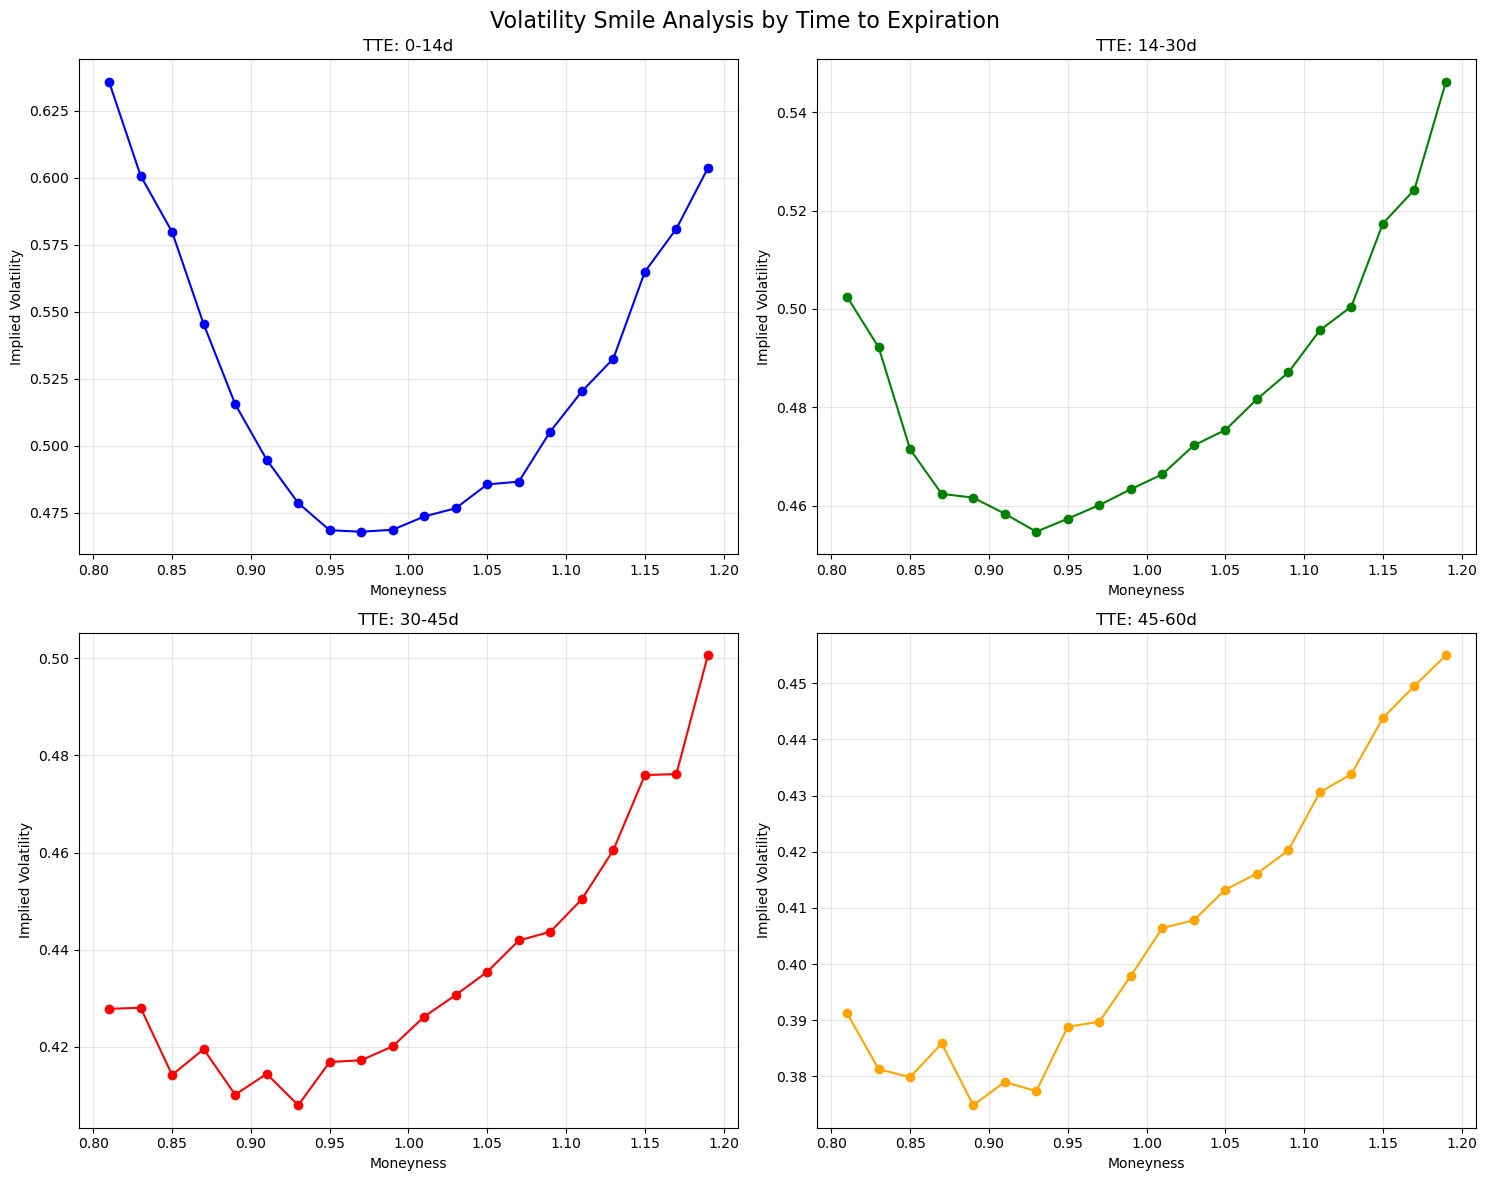


VOLATILITY SMILE ANALYSIS

Implied Volatility Statistics by TTE:
         count    mean     std     min     max
tte_bin                                       
0-14d     5702  0.5136  0.1398   0.248  1.0348
14-30d    9469  0.4773  0.0718  0.2558  0.7782
30-45d    5411  0.4326  0.0511  0.3158  0.6162
45-60d    1812  0.4083  0.0475  0.3066   0.547


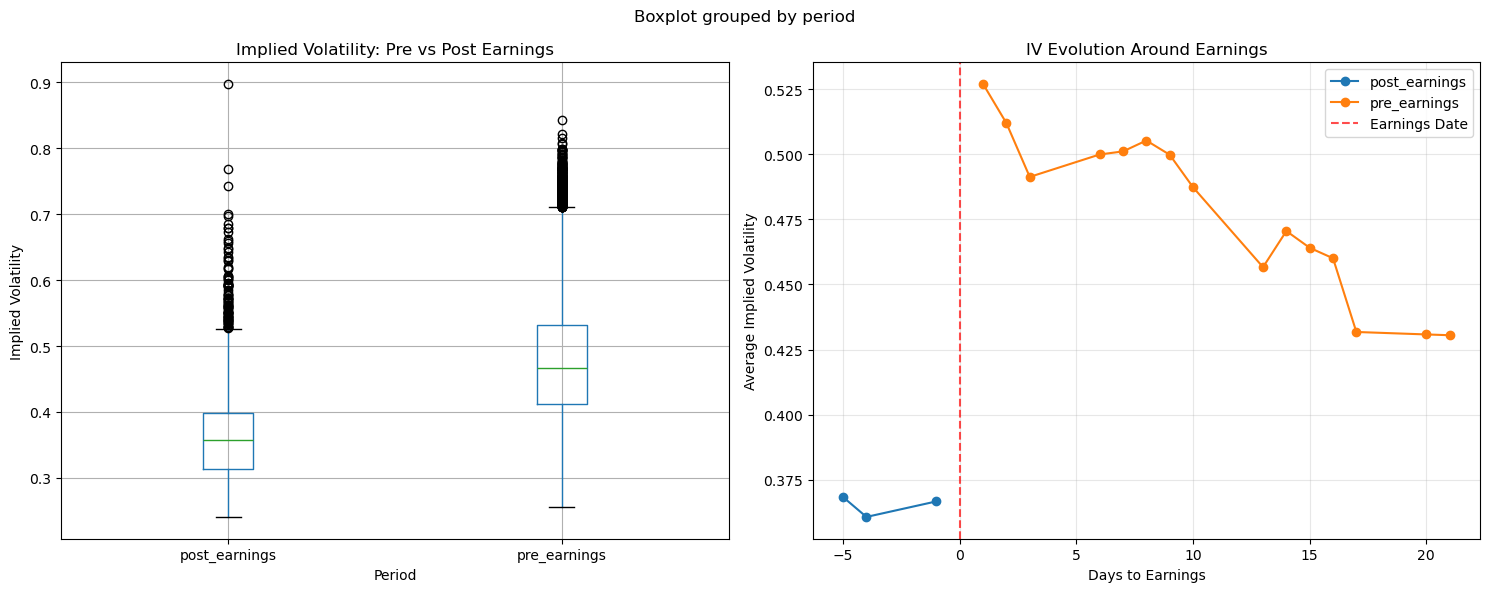


EARNINGS EVENT STUDY ANALYSIS
Pre-earnings IV: Mean = 0.4800, Std = 0.0911, N = 14812
Post-earnings IV: Mean = 0.3654, Std = 0.0664, N = 3351
T-test: t-stat = 68.7541, p-value = 0.0000
*** Significant difference in pre vs post earnings IV ***


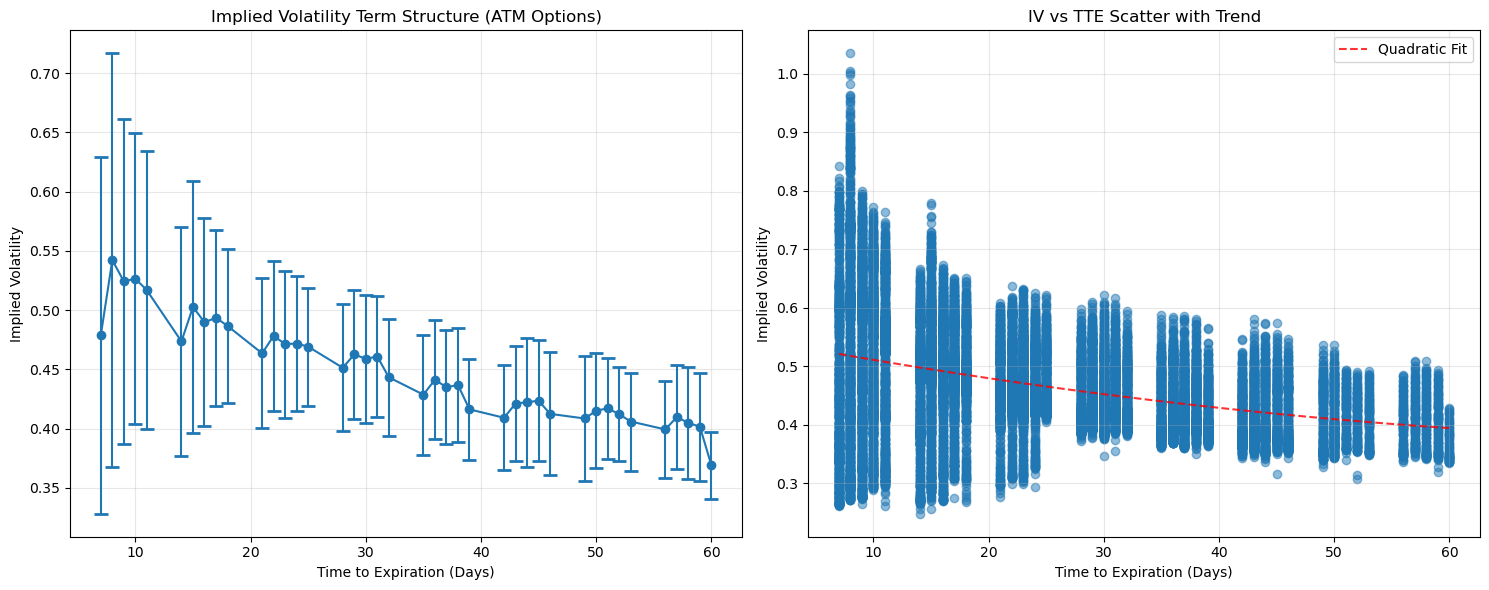


IMPLIED VOLATILITY TERM STRUCTURE

Term Structure Summary:
    tte    mean     std  count
0     7  0.4788  0.1507    810
1     8  0.5422  0.1745   1116
2     9  0.5241   0.137   1173
3    10  0.5266  0.1229    981
4    11  0.5167  0.1174    836
5    14  0.4735  0.0969    786
6    15  0.5026   0.106   1031
7    16  0.4897  0.0876    998
8    17  0.4935   0.074    913
9    18  0.4866  0.0646    709
10   21  0.4635  0.0632    688
11   22  0.4782  0.0634    920
12   23  0.4713  0.0621    885
13   24  0.4717  0.0567    781
14   25  0.4691  0.0497    636
15   28  0.4513  0.0536    502
16   29  0.4626  0.0544    709
17   30  0.4589  0.0542    697
18   31  0.4608  0.0511    599
19   32  0.4433  0.0493    509
20   35  0.4286  0.0507    463
21   36  0.4412  0.0502    646
22   37  0.4349  0.0483    602
23   38  0.4368  0.0482    515
24   39  0.4162  0.0428    408
25   42  0.4091  0.0443    428
26   43  0.4211  0.0488    510
27   44  0.4222  0.0544    378
28   45  0.4235  0.0512    353
29   46  0

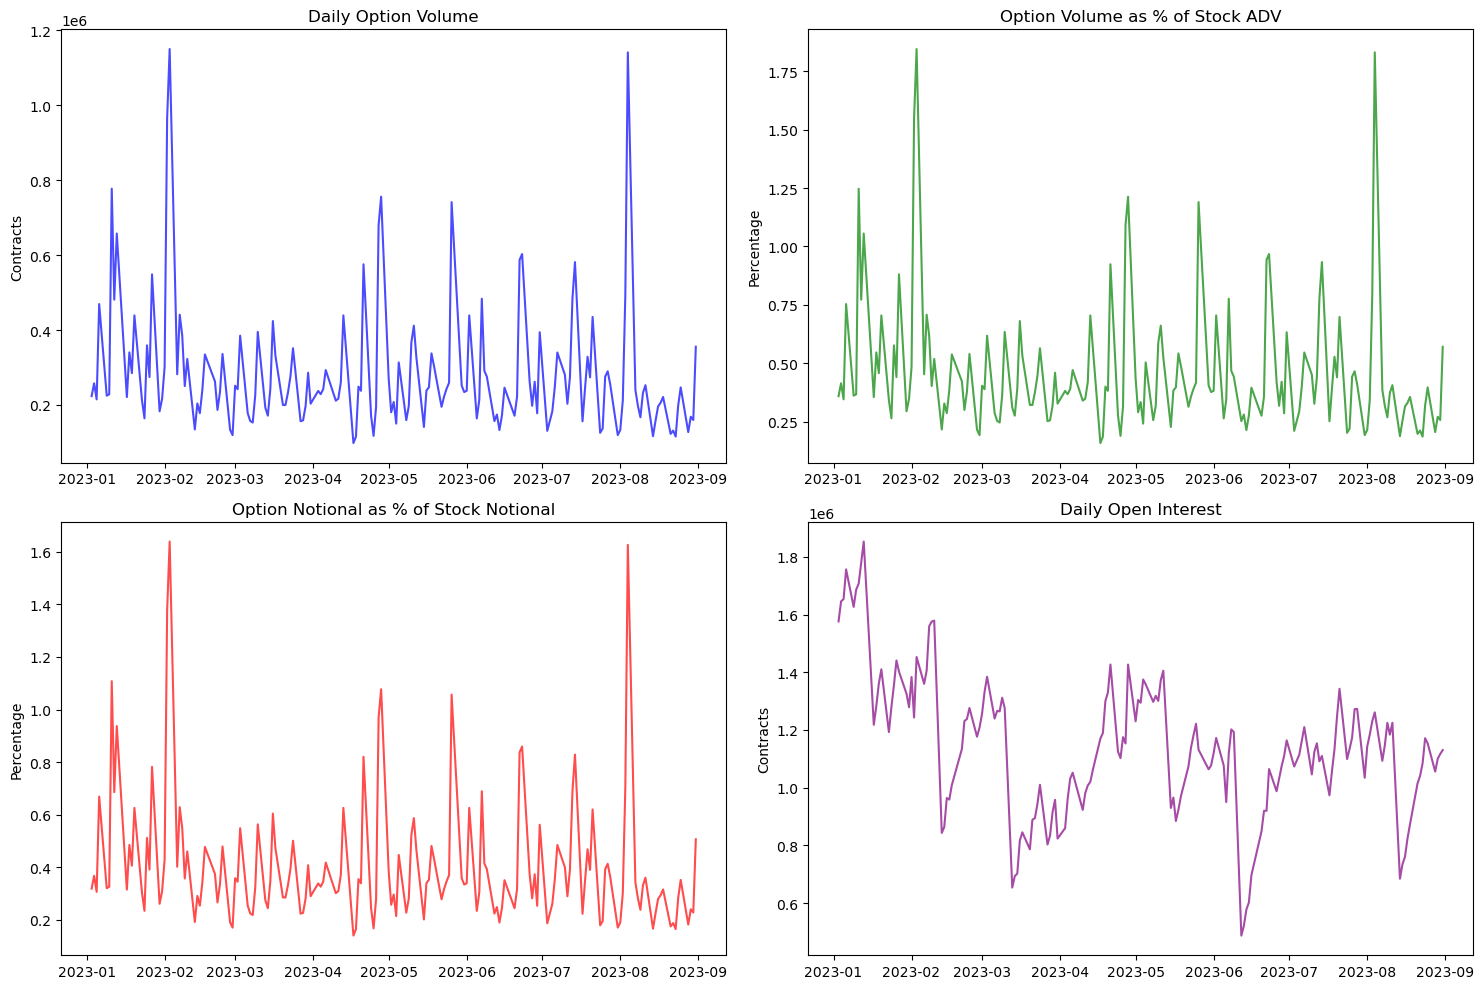


📊 Volume Analysis Summary:
Stock ADV: 62,337,746
Average Daily Option Volume: 283,707
Average Volume Ratio: 0.5%
Average Notional Ratio: 0.4%
Available columns in earnings_options_df: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume', 'tte', 'underlying_price', 'underlying_price_stock', 'mid_price', 'moneyness', 'bid_ask_spread', 'log_moneyness', 'earnings_date', 'days_to_earnings', 'ticker']
Available columns in realized_vol_df: ['secid', 'date', 'low', 'high', 'close', 'volume', 'return', 'cfadj', 'open', 'cfret', 'shrout', 'log_returns', 'realized_vol_5d', 'ewm_vol_5d', 'parkinson_vol_5d', 'realized_vol_10d', 'ewm_vol_10d', 'parkinson_vol_10d', 'realized_vol_21d', 'ewm_vol_21d', 'parkinson_vol_21d', 'realized_vol_30d', 'ewm_vol_30d', 'parkinson_vol_30d']
Available feature columns: ['impl_volatility', 'bid_ask_spread', 'tte', 'moneyness']
Missing columns: ['volume']
Built r

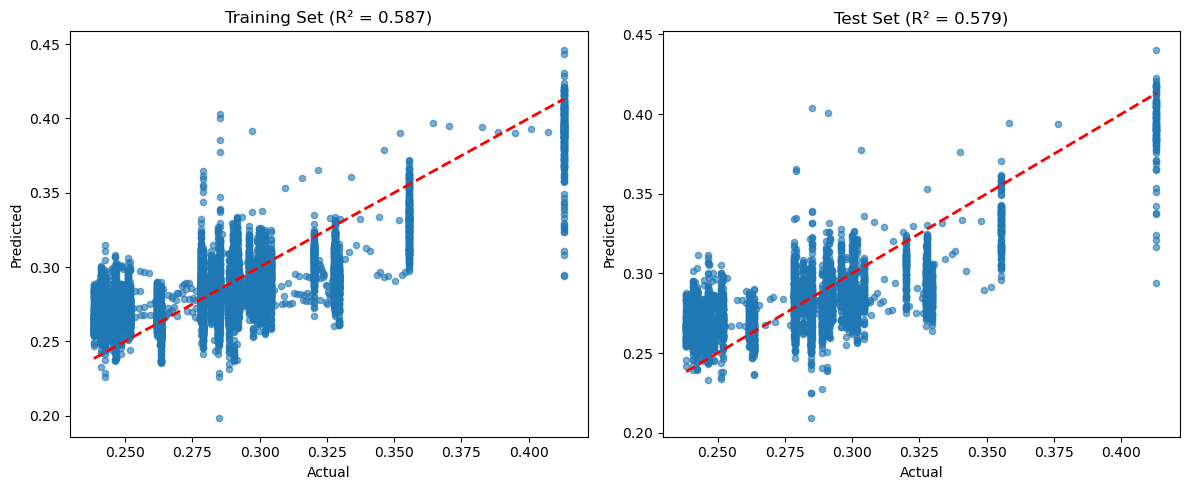


✅ Single-name case study complete for AMZN

📊 Case Study Results for AMZN:
Regression data points: 15191
Test R²: 0.579
Test RMSE: 0.0226


In [93]:
# Run single-name case study for AAPL
case_study = run_single_name_case_study(
    pipeline=pipeline,
    ticker='AMZN',
    start_date='2023-01-01',
    end_date='2024-12-31'
)

if case_study:
    print(f"\n📊 Case Study Results for {case_study['ticker']}:")
    print(f"Regression data points: {len(case_study['regression_data'])}")
    print(f"Test R²: {case_study['regression_results']['test_r2']:.3f}")
    print(f"Test RMSE: {case_study['regression_results']['test_rmse']:.4f}")


SINGLE-NAME CASE STUDY: AAPL
Fetching security information from OptionMetrics...
Retrieved 1 securities
Fetching earnings announcement dates from Compustat...
Retrieved 8 earnings announcements
Fetching stock prices from OptionMetrics...
Retrieved 167 stock price records
Fetching option data from OptionMetrics...
Executing options query...
Available columns in options data: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume']
Retrieved 351292 option records
Calculated realized volatility estimators for 167 observations
Enhanced 351292 option records with calculated metrics
Applying filters to 351,292 records...
Available columns: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume', 'tte', 'underlying_price', 'underlying_price_stock', 'mid_price', 'moneyness', 'bid_ask_sp

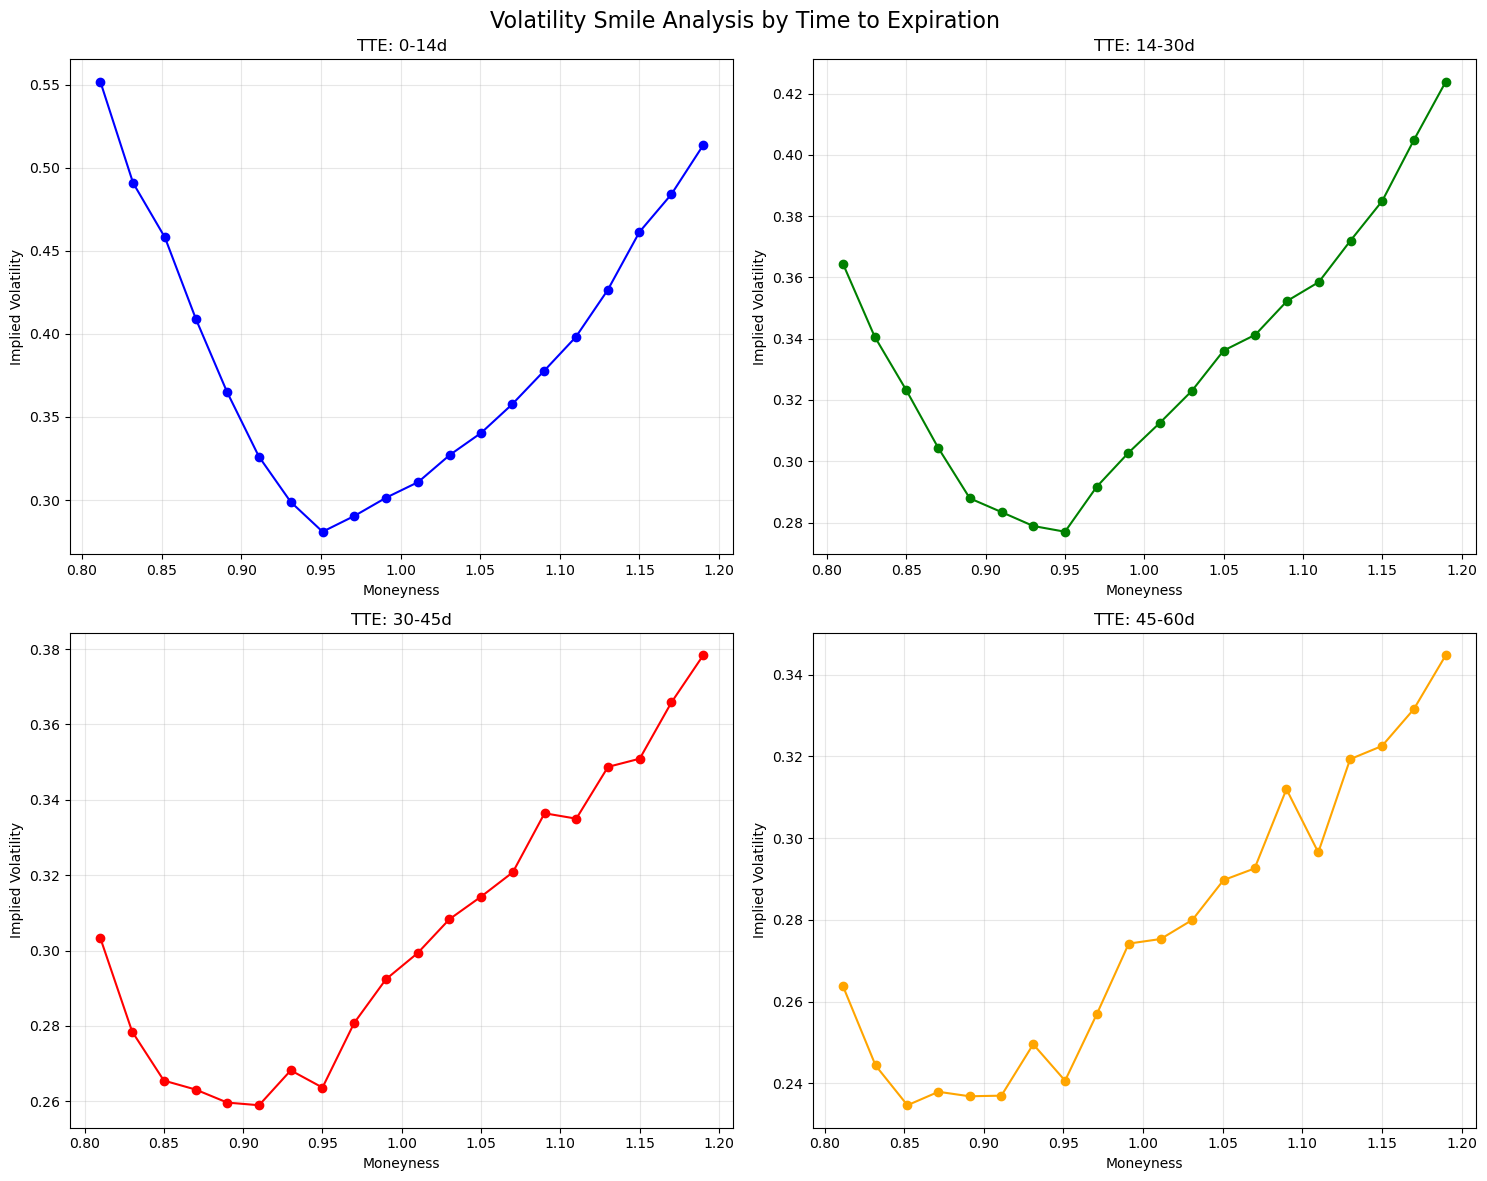


VOLATILITY SMILE ANALYSIS

Implied Volatility Statistics by TTE:
         count    mean     std     min     max
tte_bin                                       
0-14d     4051  0.3643  0.1036   0.135  0.8277
14-30d    7230  0.3274  0.0661  0.1342  0.5977
30-45d    4314  0.3029  0.0607  0.1533  0.5219
45-60d    1205  0.2746  0.0561  0.1631    0.43


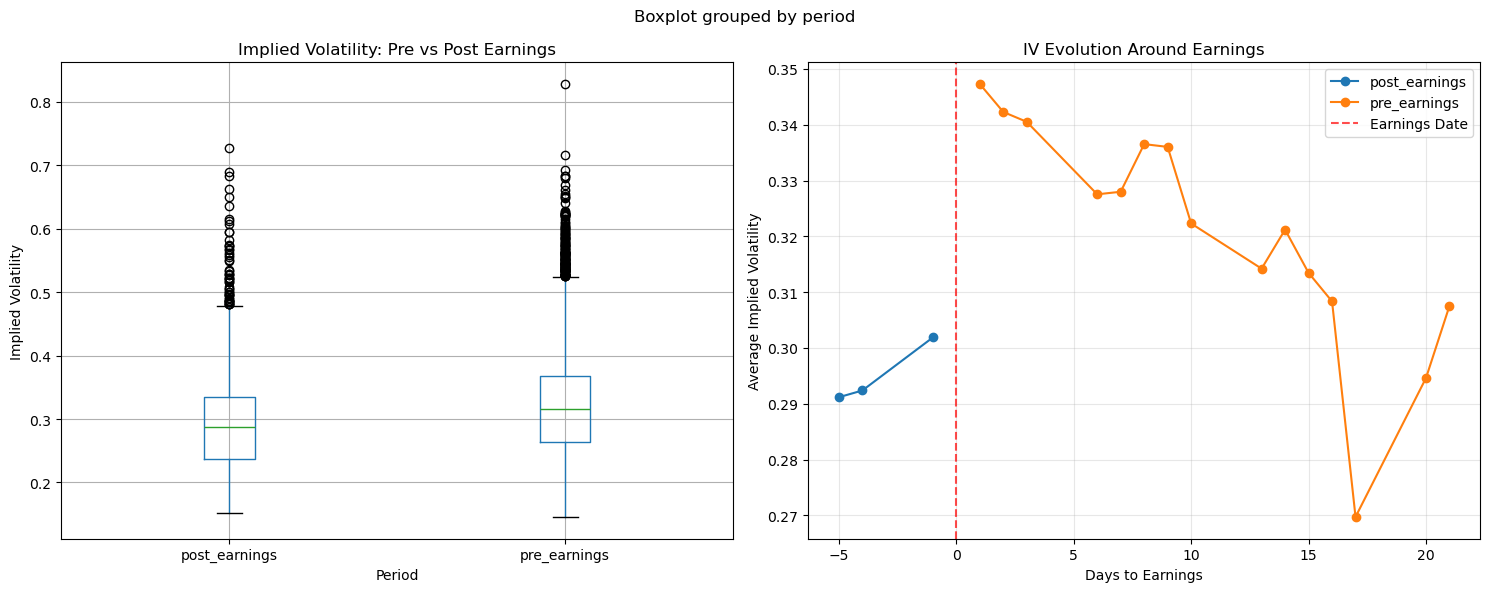


EARNINGS EVENT STUDY ANALYSIS
Pre-earnings IV: Mean = 0.3216, Std = 0.0770, N = 11023
Post-earnings IV: Mean = 0.2956, Std = 0.0770, N = 2037
T-test: t-stat = 14.0263, p-value = 0.0000
*** Significant difference in pre vs post earnings IV ***


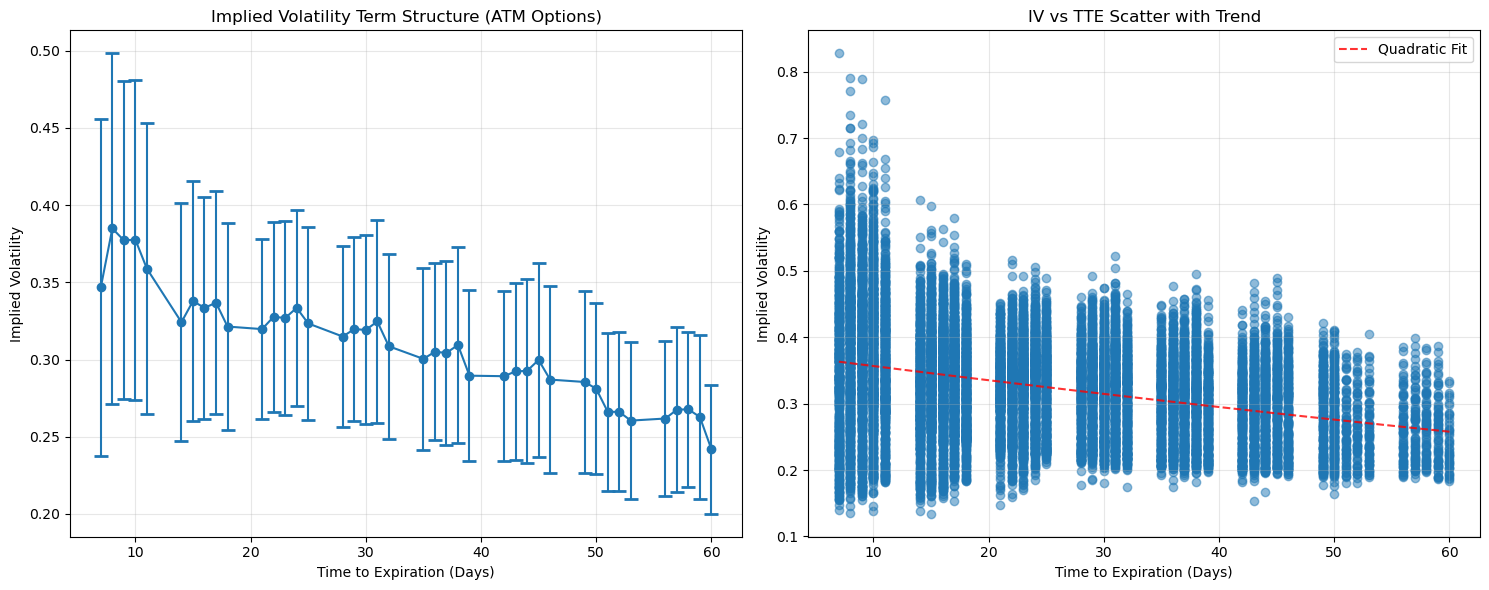


IMPLIED VOLATILITY TERM STRUCTURE

Term Structure Summary:
    tte    mean     std  count
0     7  0.3467  0.1093    544
1     8  0.3849  0.1134    758
2     9  0.3772   0.103    823
3    10  0.3776  0.1036    757
4    11  0.3588  0.0944    577
5    14  0.3242  0.0772    592
6    15  0.3378  0.0775    748
7    16  0.3335   0.072    765
8    17  0.3368   0.072    722
9    18  0.3213  0.0671    560
10   21  0.3197  0.0583    527
11   22  0.3277  0.0616    665
12   23  0.3269  0.0626    672
13   24  0.3335  0.0633    626
14   25  0.3234  0.0622    461
15   28  0.3149  0.0588    401
16   29  0.3197  0.0595    543
17   30  0.3192  0.0612    540
18   31  0.3247  0.0659    511
19   32  0.3086  0.0599    384
20   35  0.3004  0.0587    359
21   36   0.305  0.0573    488
22   37  0.3043  0.0595    479
23   38  0.3094  0.0636    439
24   39  0.2895  0.0553    313
25   42  0.2892   0.055    321
26   43  0.2923  0.0574    400
27   44  0.2927  0.0595    332
28   45  0.2997  0.0628    288
29   46   

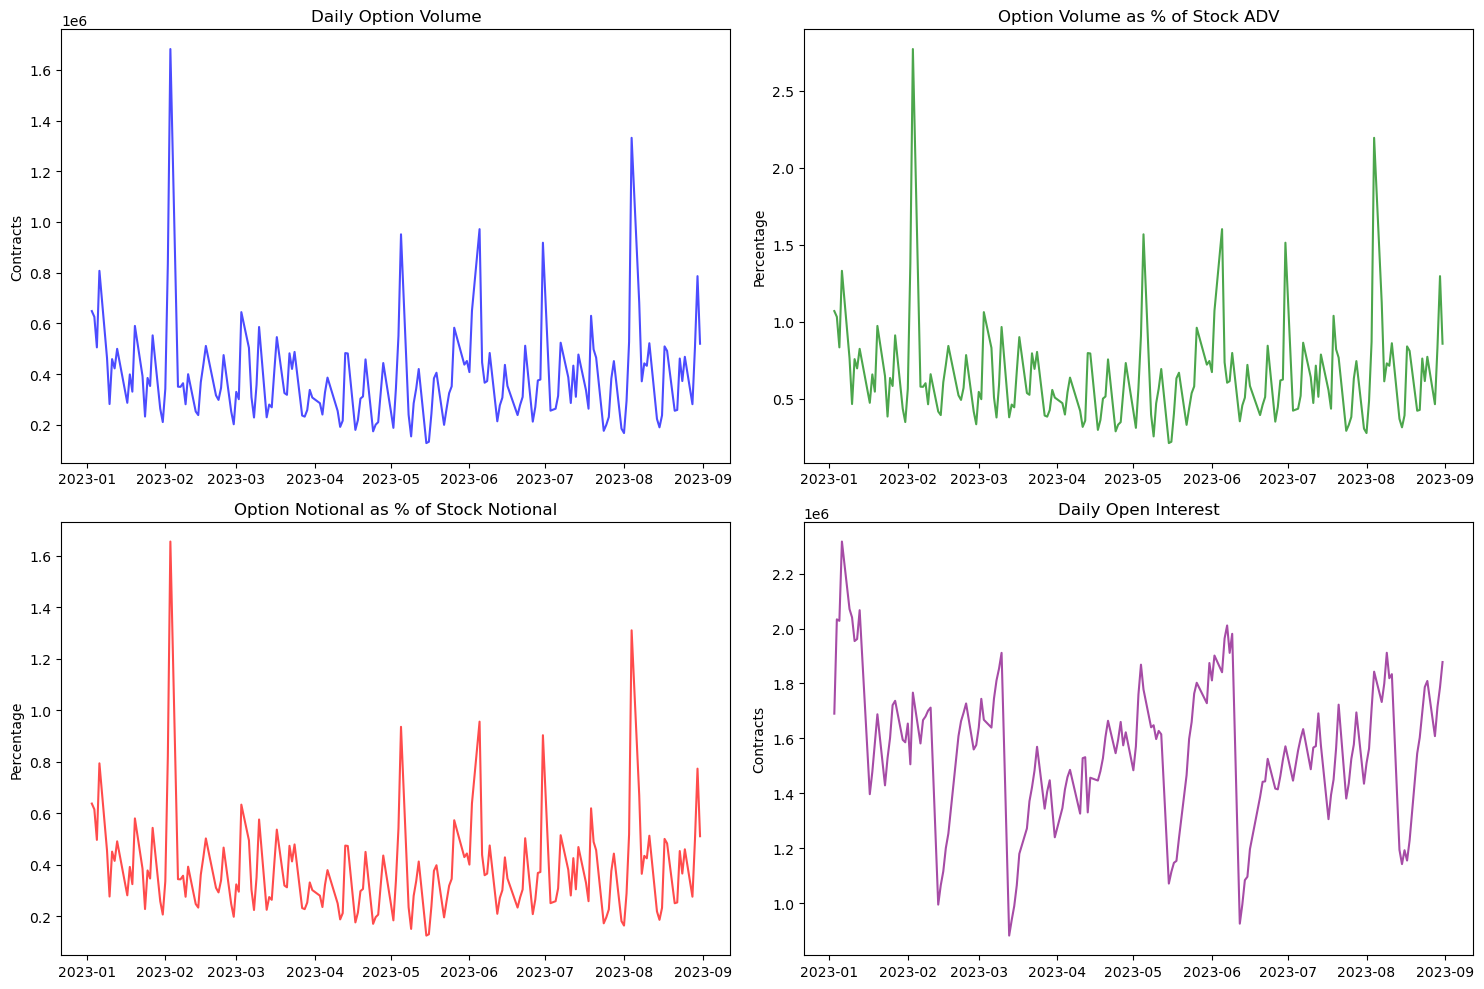


📊 Volume Analysis Summary:
Stock ADV: 60,686,220
Average Daily Option Volume: 388,556
Average Volume Ratio: 0.6%
Average Notional Ratio: 0.4%
Available columns in earnings_options_df: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume', 'tte', 'underlying_price', 'underlying_price_stock', 'mid_price', 'moneyness', 'bid_ask_spread', 'log_moneyness', 'earnings_date', 'days_to_earnings', 'ticker']
Available columns in realized_vol_df: ['secid', 'date', 'low', 'high', 'close', 'volume', 'return', 'cfadj', 'open', 'cfret', 'shrout', 'log_returns', 'realized_vol_5d', 'ewm_vol_5d', 'parkinson_vol_5d', 'realized_vol_10d', 'ewm_vol_10d', 'parkinson_vol_10d', 'realized_vol_21d', 'ewm_vol_21d', 'parkinson_vol_21d', 'realized_vol_30d', 'ewm_vol_30d', 'parkinson_vol_30d']
Available feature columns: ['impl_volatility', 'bid_ask_spread', 'tte', 'moneyness']
Missing columns: ['volume']
Built r

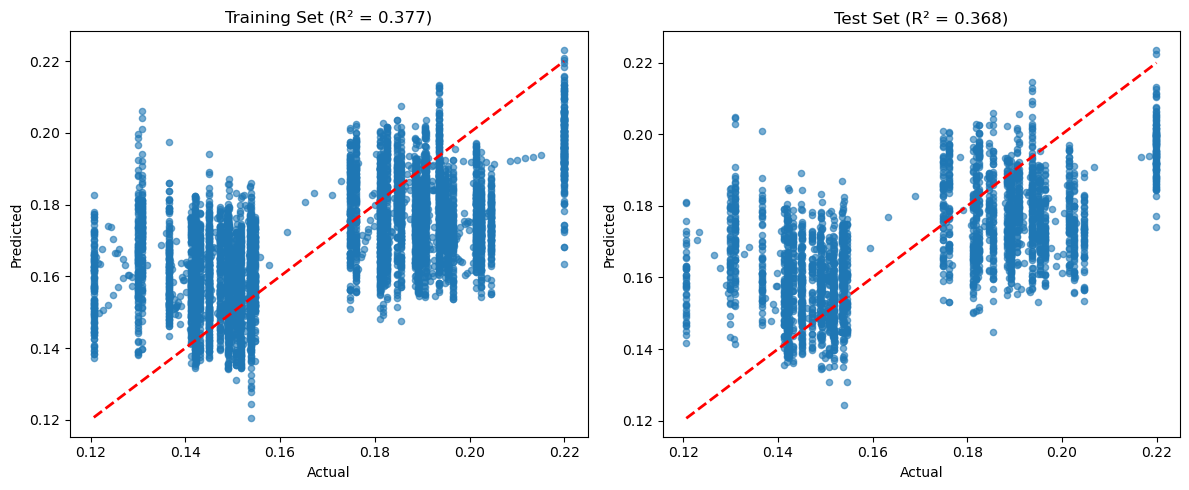


✅ Single-name case study complete for AAPL

📊 Case Study Results for AAPL:
Regression data points: 9260
Test R²: 0.368
Test RMSE: 0.0204


In [95]:
# Run single-name case study for AAPL
case_study = run_single_name_case_study(
    pipeline=pipeline,
    ticker='AAPL',
    start_date='2023-01-01',
    end_date='2024-12-31'
)

if case_study:
    print(f"\n📊 Case Study Results for {case_study['ticker']}:")
    print(f"Regression data points: {len(case_study['regression_data'])}")
    print(f"Test R²: {case_study['regression_results']['test_r2']:.3f}")
    print(f"Test RMSE: {case_study['regression_results']['test_rmse']:.4f}")


SINGLE-NAME CASE STUDY: MSFT
Fetching security information from OptionMetrics...
Retrieved 1 securities
Fetching earnings announcement dates from Compustat...
Retrieved 8 earnings announcements
Fetching stock prices from OptionMetrics...
Retrieved 167 stock price records
Fetching option data from OptionMetrics...
Executing options query...
Available columns in options data: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume']
Retrieved 418158 option records
Calculated realized volatility estimators for 167 observations
Enhanced 418158 option records with calculated metrics
Applying filters to 418,158 records...
Available columns: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume', 'tte', 'underlying_price', 'underlying_price_stock', 'mid_price', 'moneyness', 'bid_ask_sp

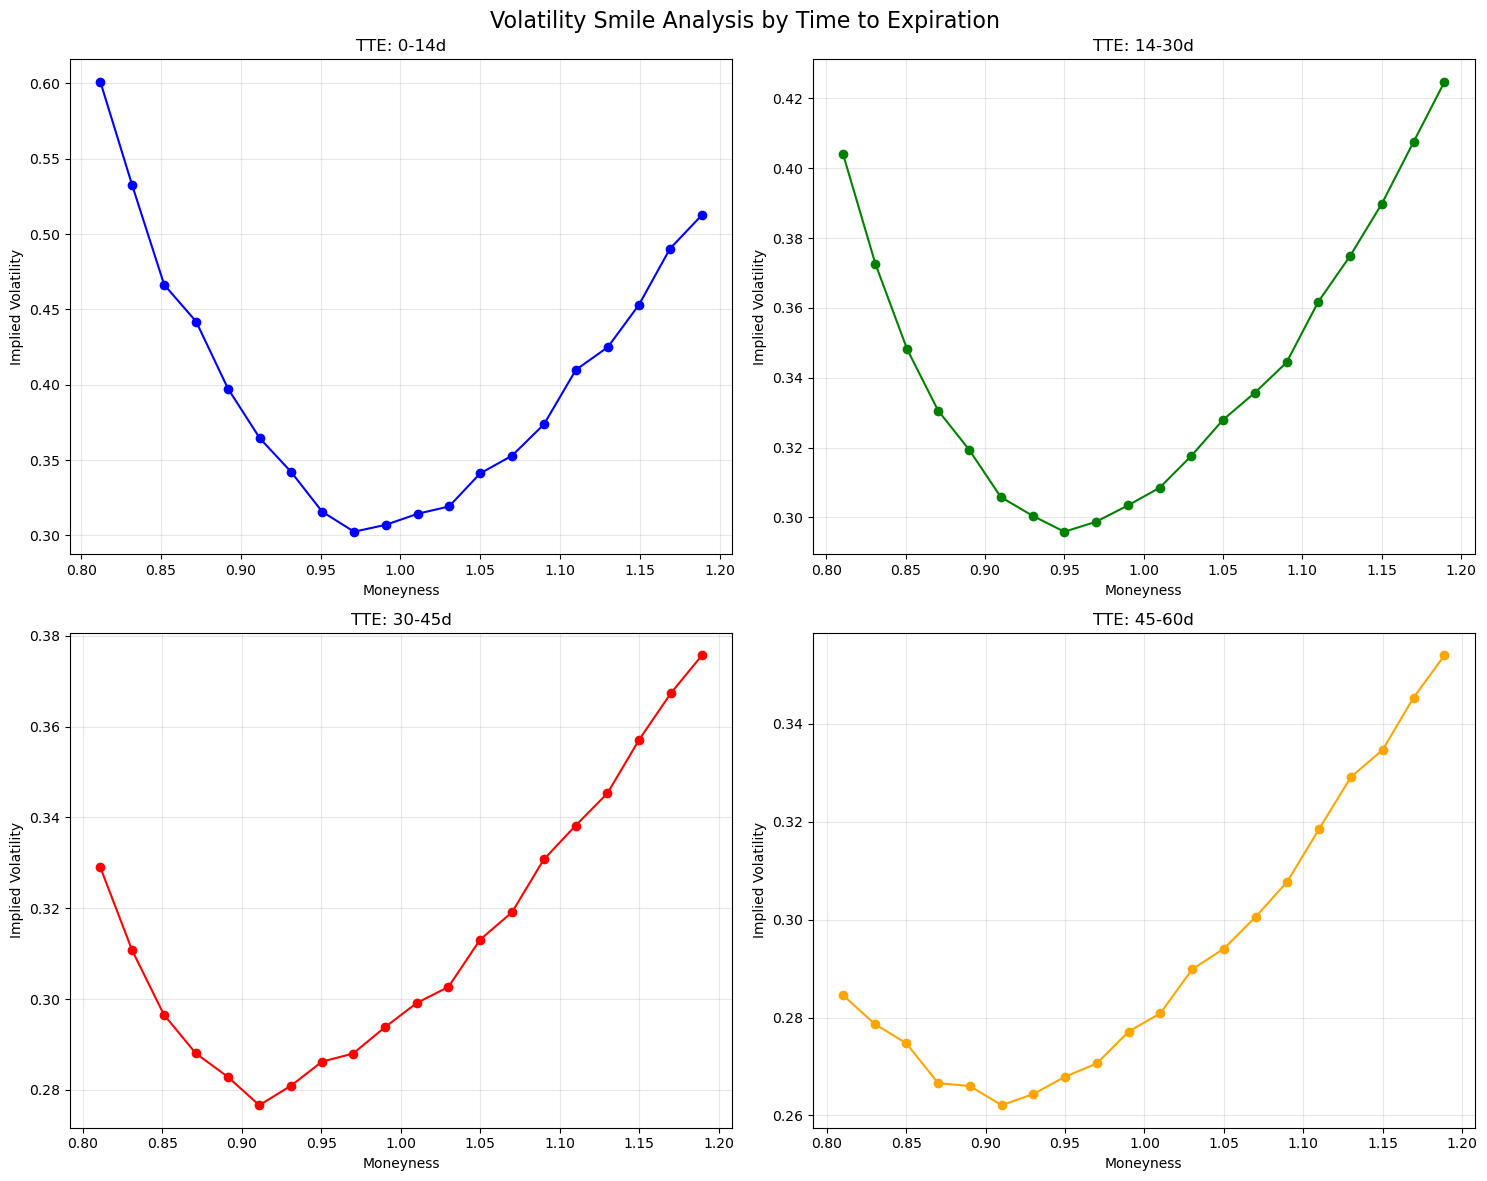


VOLATILITY SMILE ANALYSIS

Implied Volatility Statistics by TTE:
         count    mean     std     min     max
tte_bin                                       
0-14d     3913   0.366  0.1109  0.1631  0.8657
14-30d    5952  0.3312  0.0626  0.1696   0.652
30-45d    3737  0.3091   0.038  0.2153   0.448
45-60d    1650  0.2906  0.0335  0.2253  0.4326


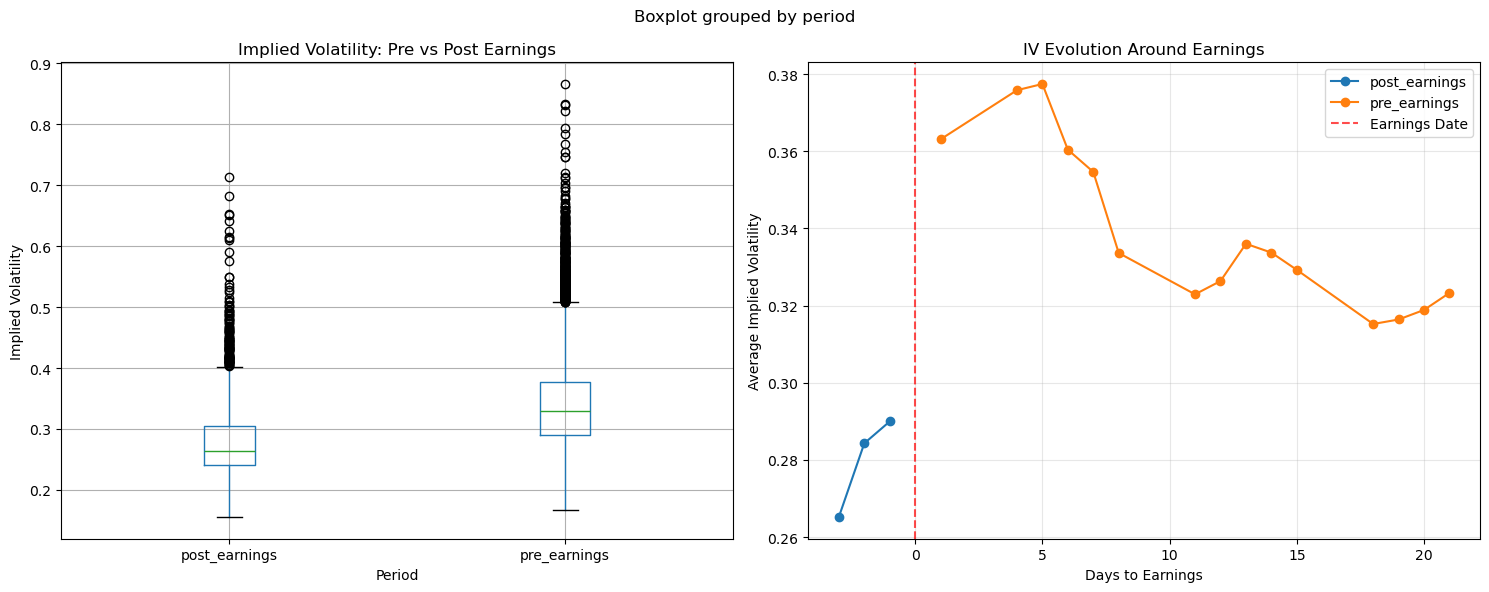


EARNINGS EVENT STUDY ANALYSIS
Pre-earnings IV: Mean = 0.3416, Std = 0.0747, N = 11221
Post-earnings IV: Mean = 0.2798, Std = 0.0614, N = 2623
T-test: t-stat = 39.3731, p-value = 0.0000
*** Significant difference in pre vs post earnings IV ***


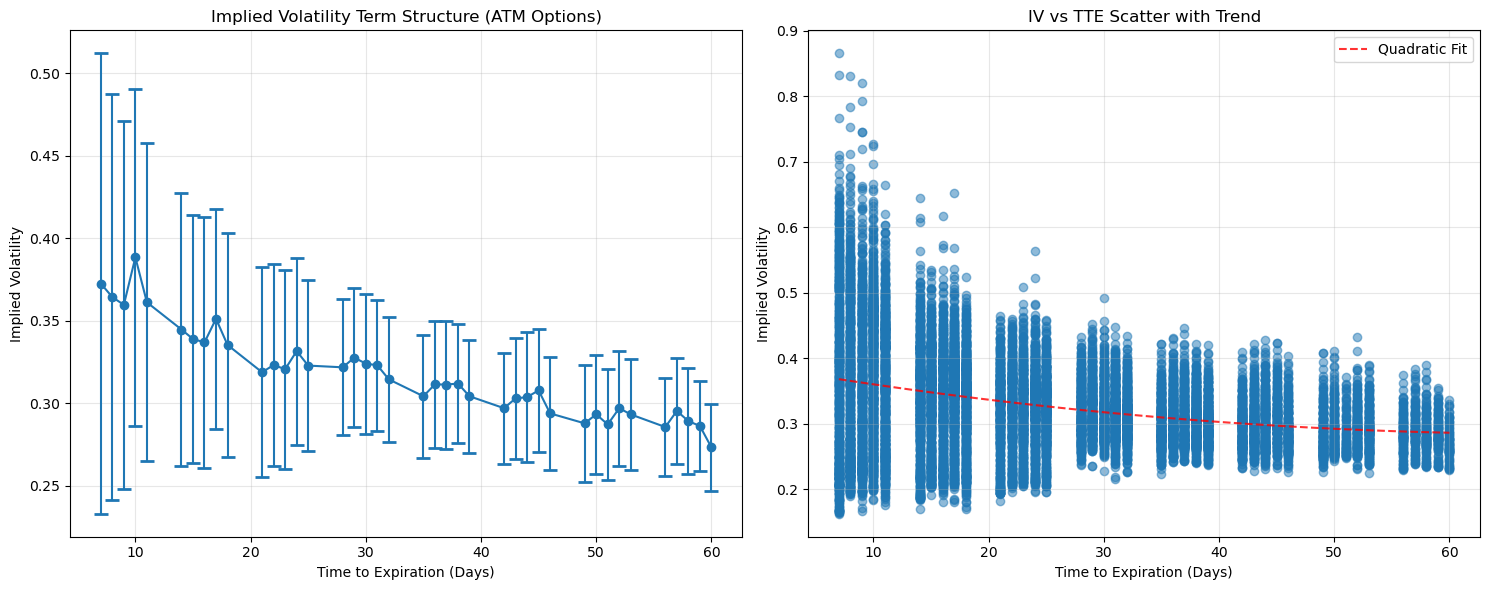


IMPLIED VOLATILITY TERM STRUCTURE

Term Structure Summary:
    tte    mean     std  count
0     7  0.3726  0.1396    578
1     8  0.3643   0.123    645
2     9  0.3596  0.1116    651
3    10  0.3884   0.102    778
4    11  0.3612  0.0964    669
5    14  0.3447  0.0828    592
6    15  0.3389  0.0754    618
7    16  0.3368  0.0762    586
8    17  0.3512  0.0666    692
9    18  0.3353  0.0681    635
10   21  0.3187  0.0637    397
11   22  0.3231   0.061    420
12   23  0.3206  0.0603    416
13   24  0.3316  0.0567    574
14   25  0.3228  0.0518    531
15   28  0.3217  0.0412    349
16   29  0.3276  0.0422    367
17   30   0.324  0.0425    367
18   31   0.323  0.0397    429
19   32  0.3144   0.038    401
20   35  0.3042  0.0373    332
21   36  0.3114  0.0385    348
22   37  0.3113  0.0388    329
23   38  0.3119  0.0364    396
24   39  0.3042  0.0344    377
25   42   0.297  0.0336    301
26   43  0.3029  0.0367    309
27   44  0.3037  0.0395    282
28   45  0.3078  0.0372    233
29   46  0

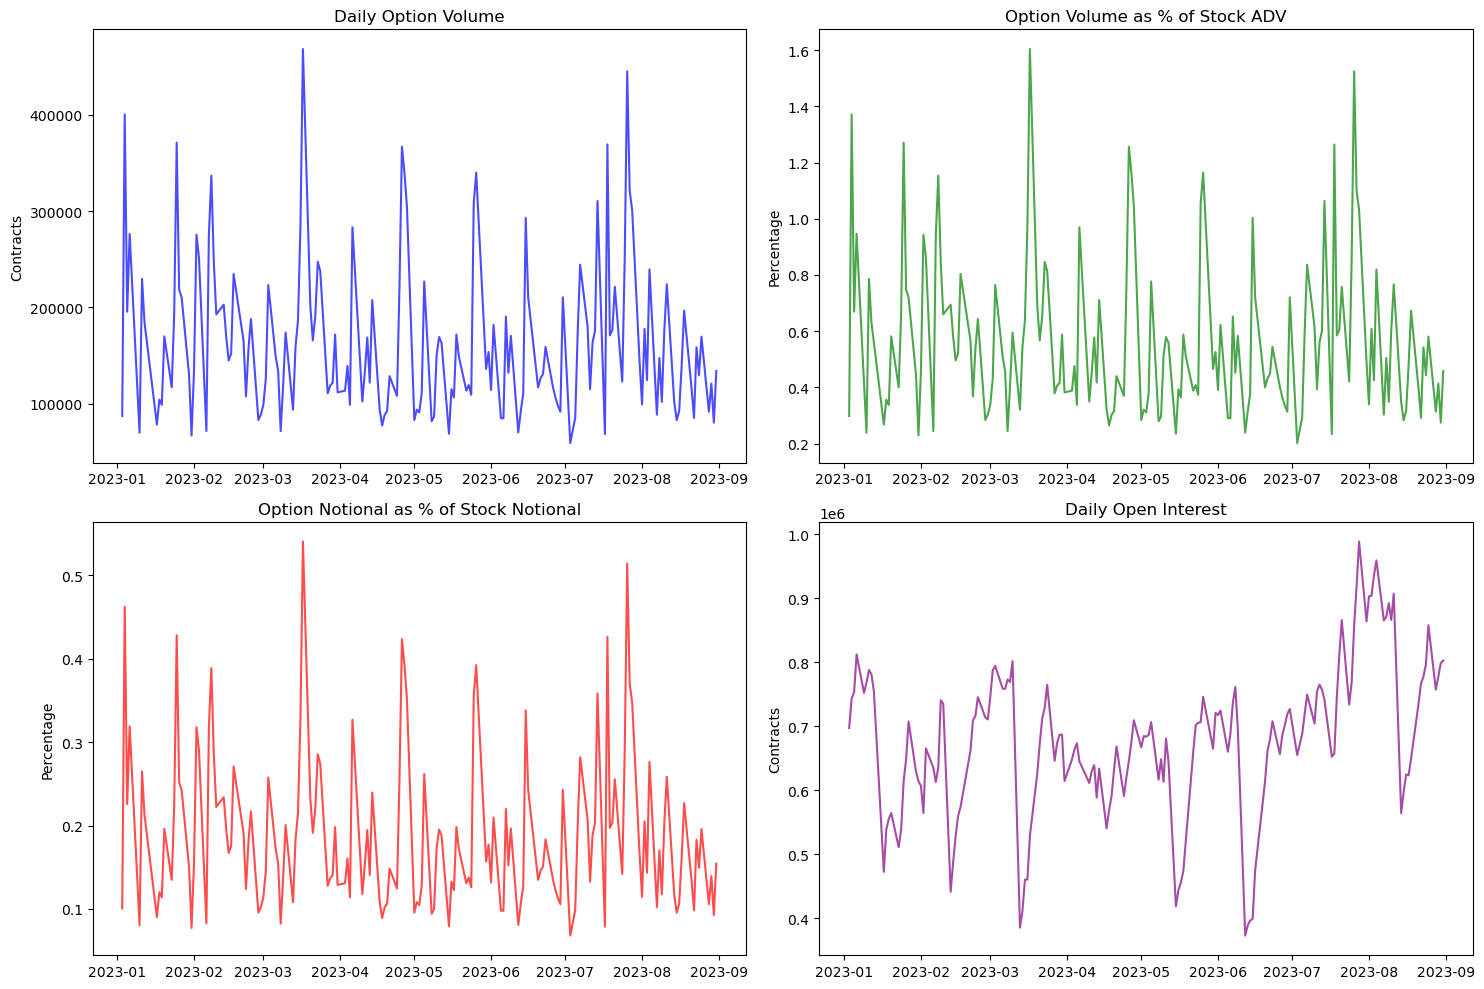


📊 Volume Analysis Summary:
Stock ADV: 29,198,875
Average Daily Option Volume: 163,555
Average Volume Ratio: 0.6%
Average Notional Ratio: 0.2%
Available columns in earnings_options_df: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume', 'tte', 'underlying_price', 'underlying_price_stock', 'mid_price', 'moneyness', 'bid_ask_spread', 'log_moneyness', 'earnings_date', 'days_to_earnings', 'ticker']
Available columns in realized_vol_df: ['secid', 'date', 'low', 'high', 'close', 'volume', 'return', 'cfadj', 'open', 'cfret', 'shrout', 'log_returns', 'realized_vol_5d', 'ewm_vol_5d', 'parkinson_vol_5d', 'realized_vol_10d', 'ewm_vol_10d', 'parkinson_vol_10d', 'realized_vol_21d', 'ewm_vol_21d', 'parkinson_vol_21d', 'realized_vol_30d', 'ewm_vol_30d', 'parkinson_vol_30d']
Available feature columns: ['impl_volatility', 'bid_ask_spread', 'tte', 'moneyness']
Missing columns: ['volume']
Built r

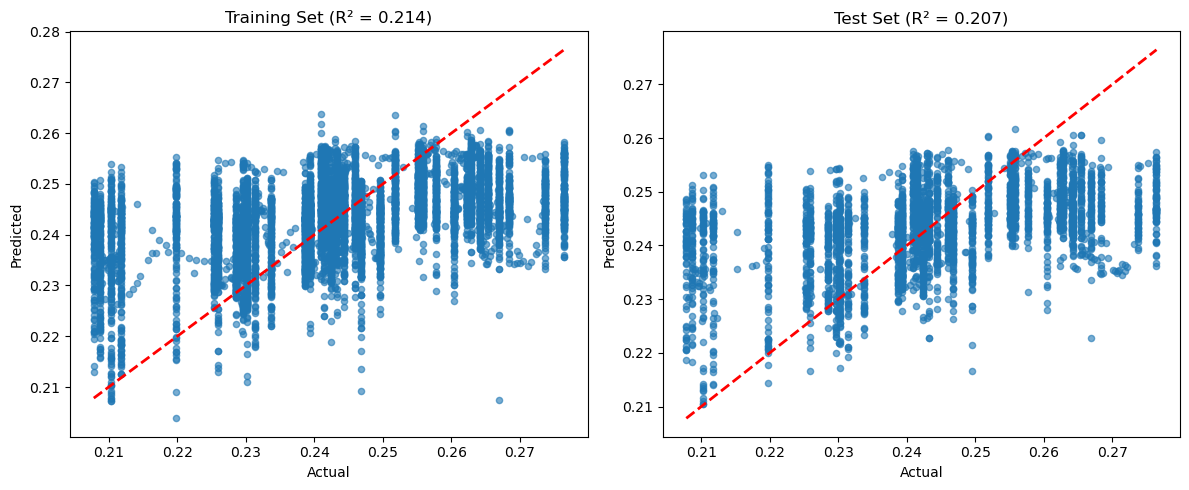


✅ Single-name case study complete for MSFT

📊 Case Study Results for MSFT:
Regression data points: 11928
Test R²: 0.207
Test RMSE: 0.0150


In [113]:
# Run single-name case study for AAPL
case_study = run_single_name_case_study(
    pipeline=pipeline,
    ticker='MSFT',
    start_date='2023-01-01',
    end_date='2024-12-31'
)

if case_study:
    print(f"\n📊 Case Study Results for {case_study['ticker']}:")
    print(f"Regression data points: {len(case_study['regression_data'])}")
    print(f"Test R²: {case_study['regression_results']['test_r2']:.3f}")
    print(f"Test RMSE: {case_study['regression_results']['test_rmse']:.4f}")


SINGLE-NAME CASE STUDY: NVDA
Fetching security information from OptionMetrics...
Retrieved 1 securities
Fetching earnings announcement dates from Compustat...
Retrieved 8 earnings announcements
Fetching stock prices from OptionMetrics...
Retrieved 167 stock price records
Fetching option data from OptionMetrics...
Executing options query...
Available columns in options data: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume']
Retrieved 602878 option records
Calculated realized volatility estimators for 167 observations
Enhanced 602878 option records with calculated metrics
Applying filters to 602,878 records...
Available columns: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume', 'tte', 'underlying_price', 'underlying_price_stock', 'mid_price', 'moneyness', 'bid_ask_sp

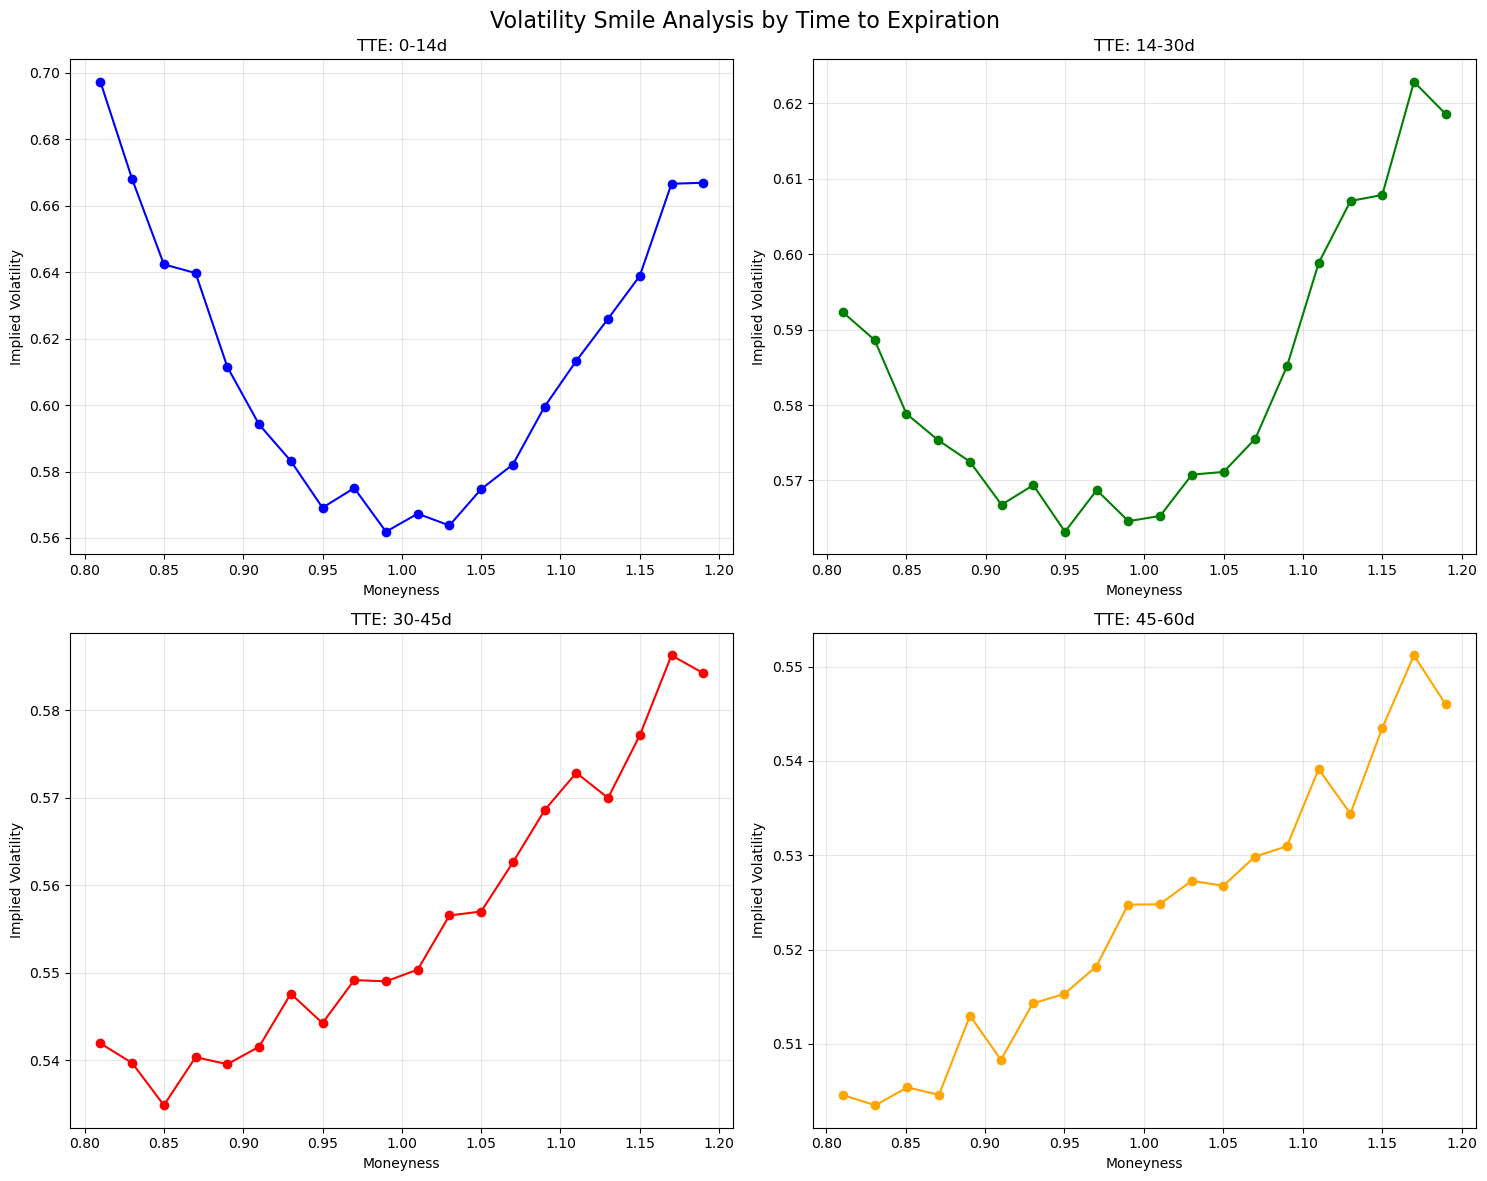


VOLATILITY SMILE ANALYSIS

Implied Volatility Statistics by TTE:
         count    mean     std     min     max
tte_bin                                       
0-14d     6109  0.6034  0.1895  0.2345   1.076
14-30d    9519    0.58  0.1119   0.282  0.8421
30-45d    6096  0.5545  0.0641  0.3746  0.7045
45-60d    1839  0.5226  0.0511  0.4026  0.6247


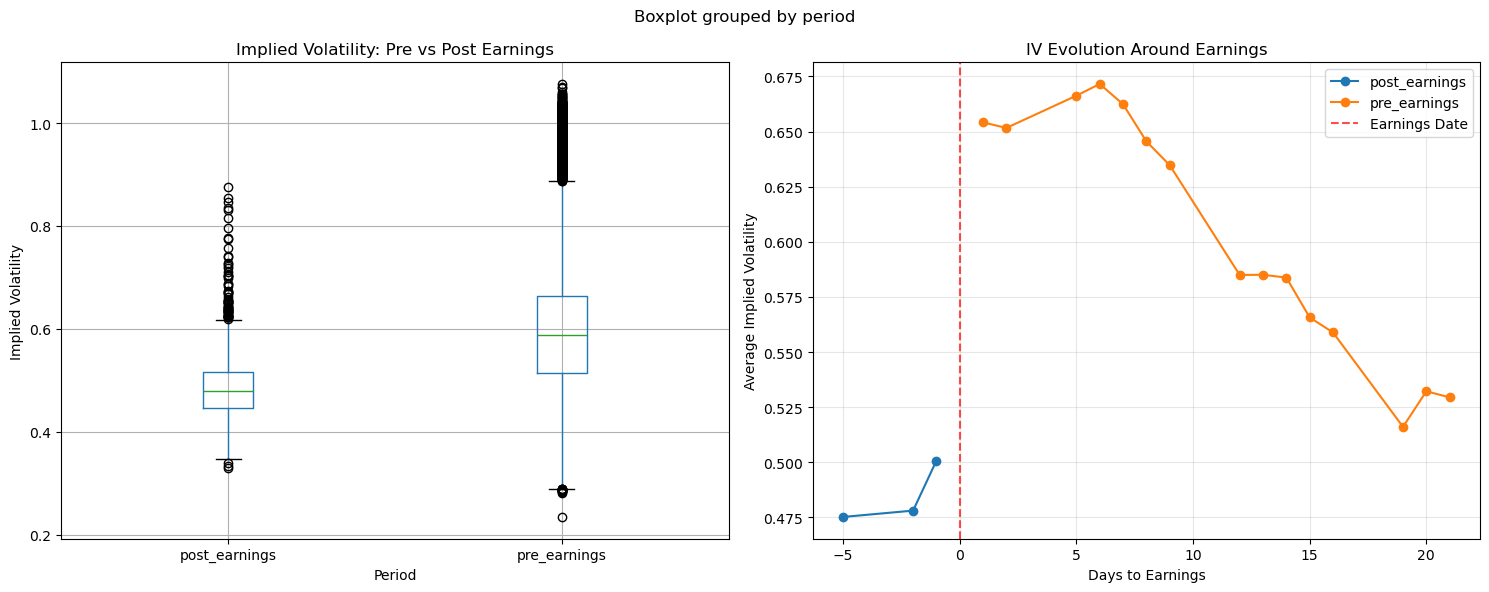


EARNINGS EVENT STUDY ANALYSIS
Pre-earnings IV: Mean = 0.6031, Std = 0.1333, N = 15359
Post-earnings IV: Mean = 0.4862, Std = 0.0530, N = 3529
T-test: t-stat = 51.1468, p-value = 0.0000
*** Significant difference in pre vs post earnings IV ***


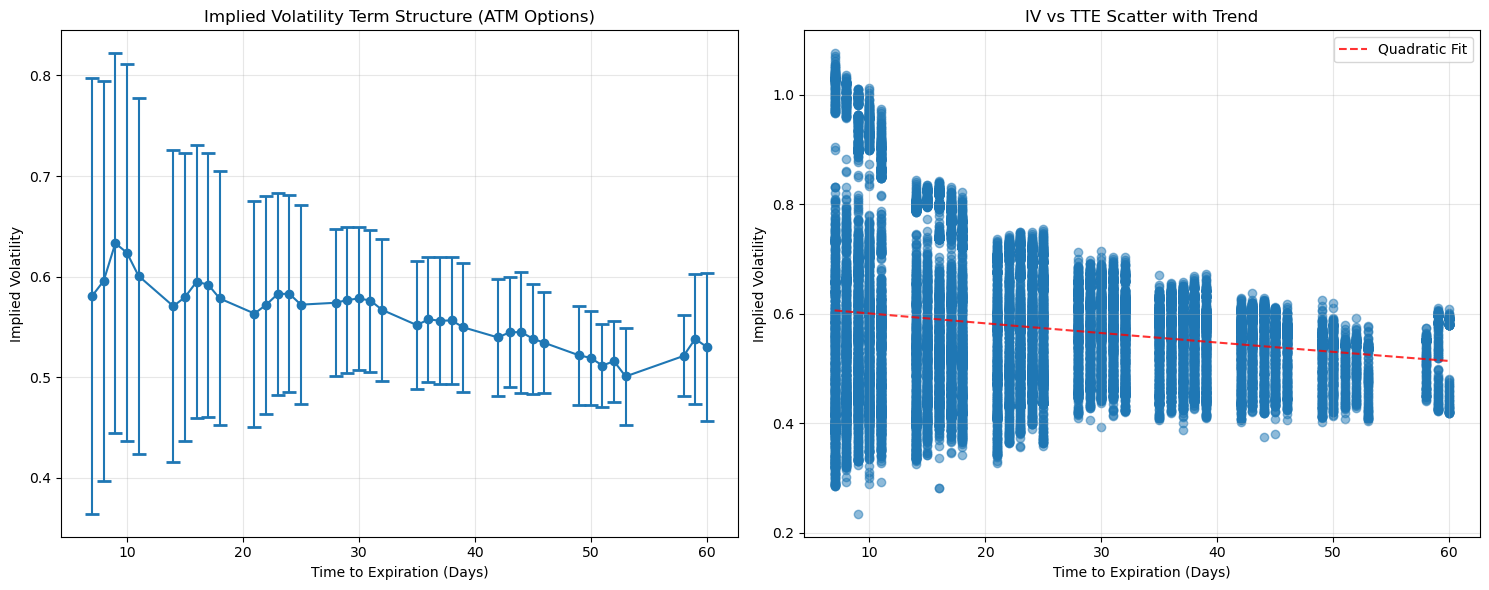


IMPLIED VOLATILITY TERM STRUCTURE

Term Structure Summary:
    tte    mean     std  count
0     7  0.5807  0.2165    933
1     8  0.5959   0.199    913
2     9  0.6332  0.1888   1192
3    10  0.6237  0.1872   1133
4    11  0.6007  0.1768   1091
5    14  0.5706   0.155    847
6    15  0.5795  0.1434    812
7    16  0.5948  0.1357    991
8    17  0.5921  0.1313   1012
9    18  0.5783  0.1263    952
10   21  0.5632  0.1124    681
11   22  0.5719  0.1085    641
12   23  0.5826  0.1001    900
13   24   0.583   0.098    892
14   25  0.5721  0.0986    787
15   28   0.574  0.0731    585
16   29  0.5767  0.0724    561
17   30  0.5783  0.0712    705
18   31  0.5761  0.0707    696
19   32  0.5669  0.0704    654
20   35  0.5517  0.0639    540
21   36  0.5574  0.0619    523
22   37  0.5561   0.063    666
23   38  0.5564  0.0633    638
24   39  0.5496   0.064    606
25   42  0.5395  0.0581    521
26   43  0.5446  0.0549    476
27   44  0.5448  0.0601    382
28   45  0.5382  0.0545    394
29   46  0

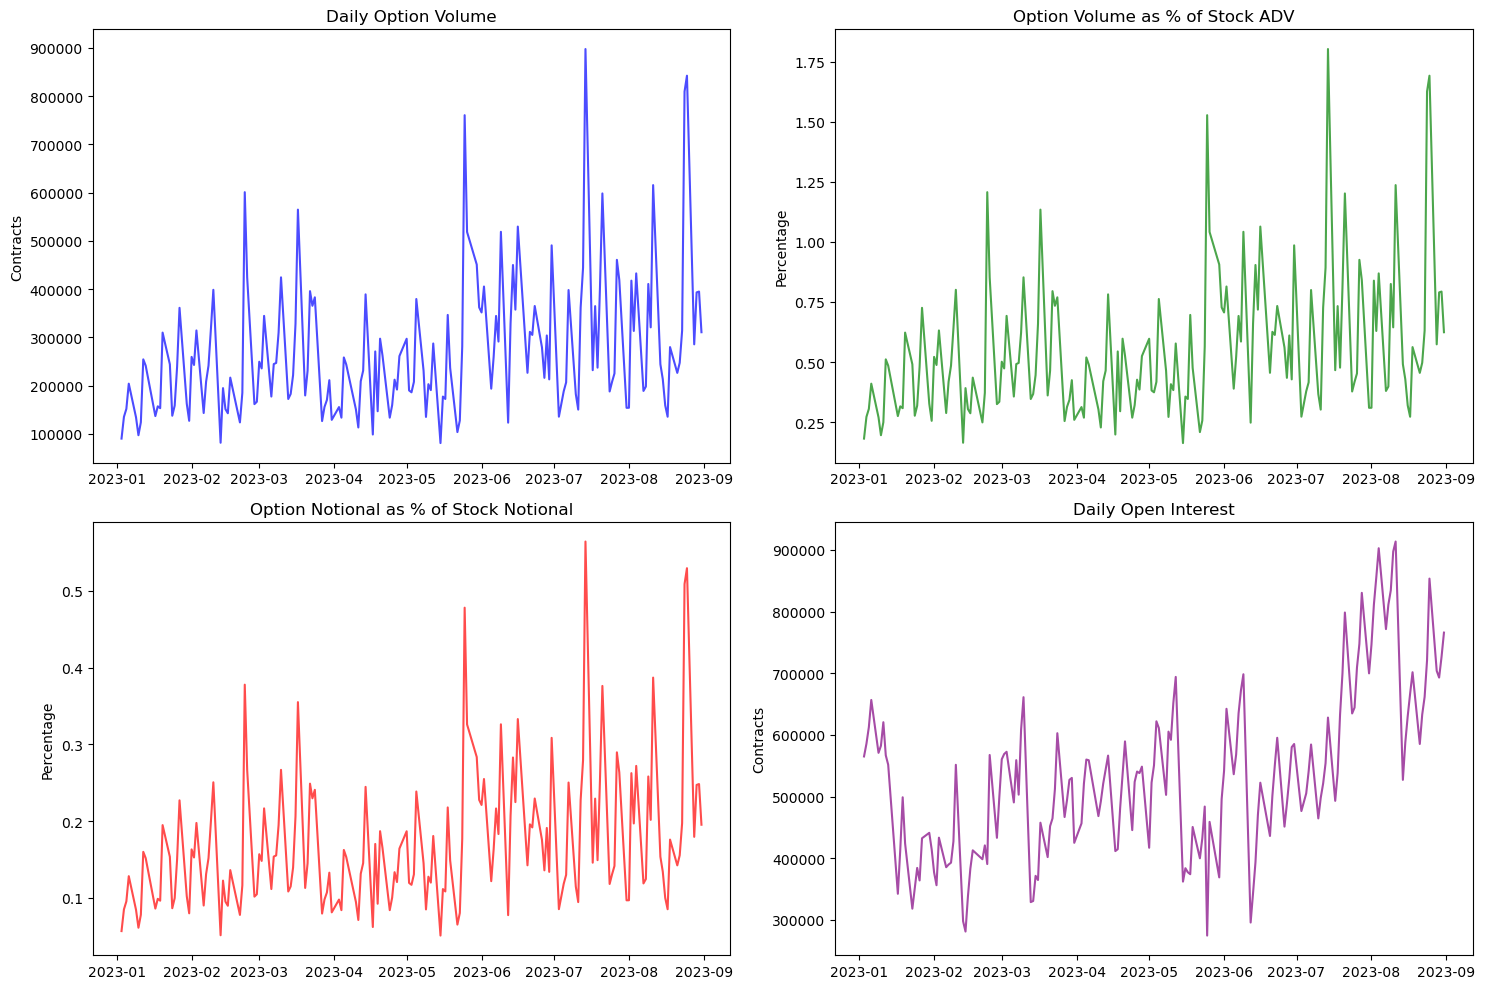


📊 Volume Analysis Summary:
Stock ADV: 49,774,439
Average Daily Option Volume: 271,340
Average Volume Ratio: 0.5%
Average Notional Ratio: 0.2%
Available columns in earnings_options_df: ['date', 'secid', 'exdate', 'strike_price', 'cp_flag', 'best_bid', 'best_offer', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'theta', 'vega', 'volume', 'tte', 'underlying_price', 'underlying_price_stock', 'mid_price', 'moneyness', 'bid_ask_spread', 'log_moneyness', 'earnings_date', 'days_to_earnings', 'ticker']
Available columns in realized_vol_df: ['secid', 'date', 'low', 'high', 'close', 'volume', 'return', 'cfadj', 'open', 'cfret', 'shrout', 'log_returns', 'realized_vol_5d', 'ewm_vol_5d', 'parkinson_vol_5d', 'realized_vol_10d', 'ewm_vol_10d', 'parkinson_vol_10d', 'realized_vol_21d', 'ewm_vol_21d', 'parkinson_vol_21d', 'realized_vol_30d', 'ewm_vol_30d', 'parkinson_vol_30d']
Available feature columns: ['impl_volatility', 'bid_ask_spread', 'tte', 'moneyness']
Missing columns: ['volume']
Built r

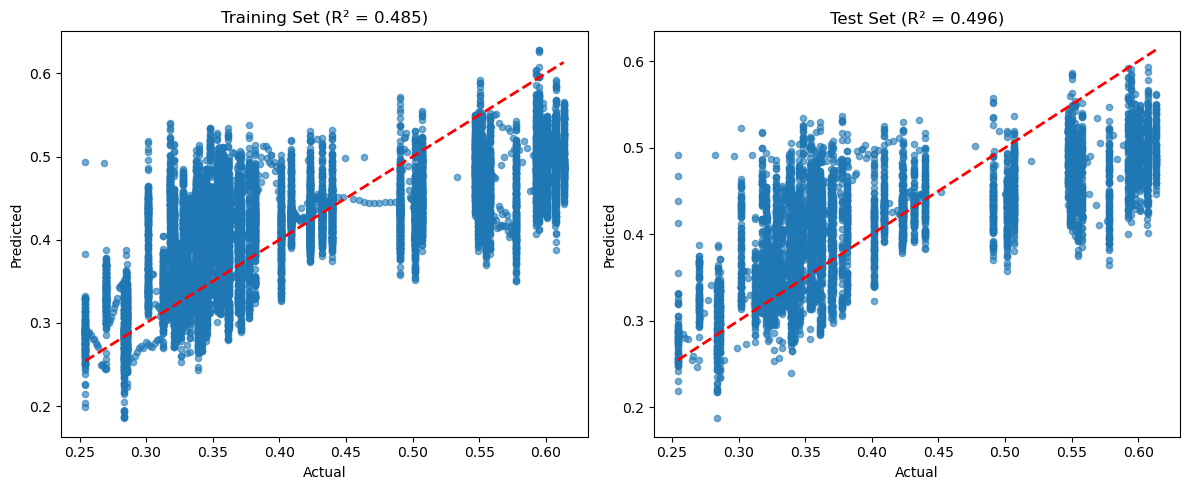


✅ Single-name case study complete for NVDA

📊 Case Study Results for NVDA:
Regression data points: 21441
Test R²: 0.496
Test RMSE: 0.0717


In [99]:
# Run single-name case study for AAPL
case_study = run_single_name_case_study(
    pipeline=pipeline,
    ticker='NVDA',
    start_date='2023-01-01',
    end_date='2024-12-31'
)

if case_study:
    print(f"\n📊 Case Study Results for {case_study['ticker']}:")
    print(f"Regression data points: {len(case_study['regression_data'])}")
    print(f"Test R²: {case_study['regression_results']['test_r2']:.3f}")
    print(f"Test RMSE: {case_study['regression_results']['test_rmse']:.4f}")

## 2. Realized Volatility Analysis

Compare different realized volatility estimators and their properties.

Calculated realized volatility estimators for 167 observations


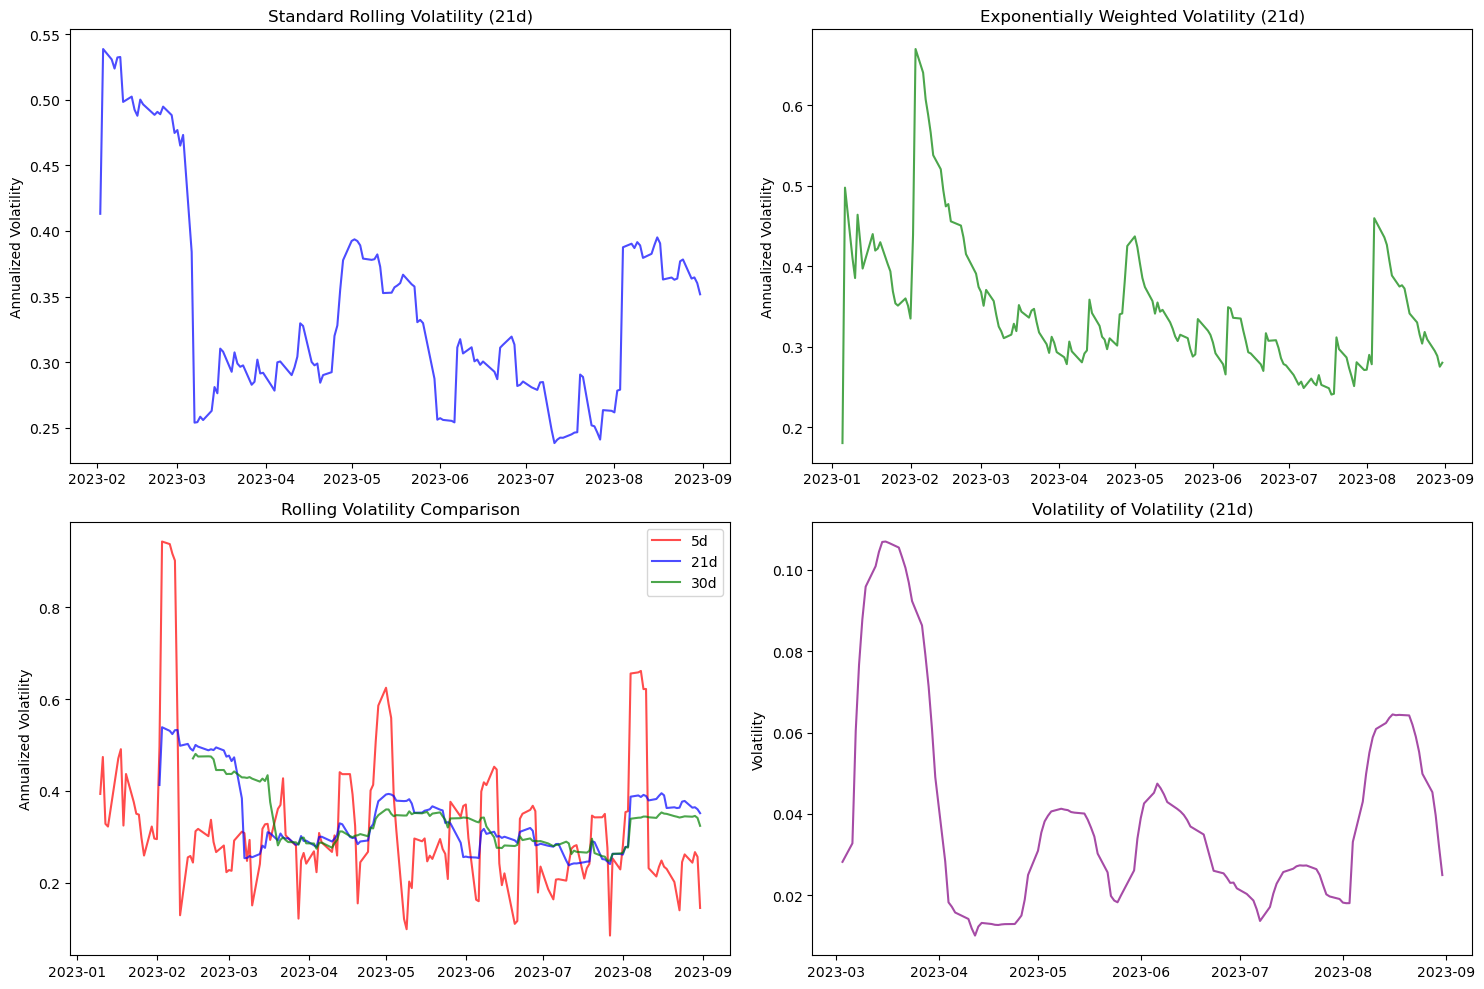


📈 Realized Volatility Summary:
5-day RV mean: 0.323
21-day RV mean: 0.340
30-day RV mean: 0.332


In [76]:
# Get stock prices for realized volatility calculation
if 'stock_prices' in pipeline.data:
    stock_prices = pipeline.data['stock_prices']
    
    # Calculate multiple realized volatility estimators
    realized_vol = calculate_realized_volatility_estimators(
        stock_prices, 
        windows=[5, 10, 21, 30]
    )
    
    # Plot different estimators
    if realized_vol is not None:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Standard rolling volatility
        axes[0,0].plot(realized_vol['date'], realized_vol['realized_vol_21d'], 'b-', alpha=0.7)
        axes[0,0].set_title('Standard Rolling Volatility (21d)')
        axes[0,0].set_ylabel('Annualized Volatility')
        
        # Exponentially weighted volatility
        axes[0,1].plot(realized_vol['date'], realized_vol['ewm_vol_21d'], 'g-', alpha=0.7)
        axes[0,1].set_title('Exponentially Weighted Volatility (21d)')
        axes[0,1].set_ylabel('Annualized Volatility')
        
        # Compare different windows
        axes[1,0].plot(realized_vol['date'], realized_vol['realized_vol_5d'], 'r-', alpha=0.7, label='5d')
        axes[1,0].plot(realized_vol['date'], realized_vol['realized_vol_21d'], 'b-', alpha=0.7, label='21d')
        axes[1,0].plot(realized_vol['date'], realized_vol['realized_vol_30d'], 'g-', alpha=0.7, label='30d')
        axes[1,0].set_title('Rolling Volatility Comparison')
        axes[1,0].set_ylabel('Annualized Volatility')
        axes[1,0].legend()
        
        # Volatility of volatility
        vol_of_vol = realized_vol['realized_vol_21d'].rolling(21).std()
        axes[1,1].plot(realized_vol['date'], vol_of_vol, 'purple', alpha=0.7)
        axes[1,1].set_title('Volatility of Volatility (21d)')
        axes[1,1].set_ylabel('Volatility')
        
        plt.tight_layout()
        plt.show()
        
        print("\n📈 Realized Volatility Summary:")
        print(f"5-day RV mean: {realized_vol['realized_vol_5d'].mean():.3f}")
        print(f"21-day RV mean: {realized_vol['realized_vol_21d'].mean():.3f}")
        print(f"30-day RV mean: {realized_vol['realized_vol_30d'].mean():.3f}")

## 3. Volume Analysis (Meeting Requirement)

Analyze option volume relative to stock average daily volume and option notional vs stock notional.

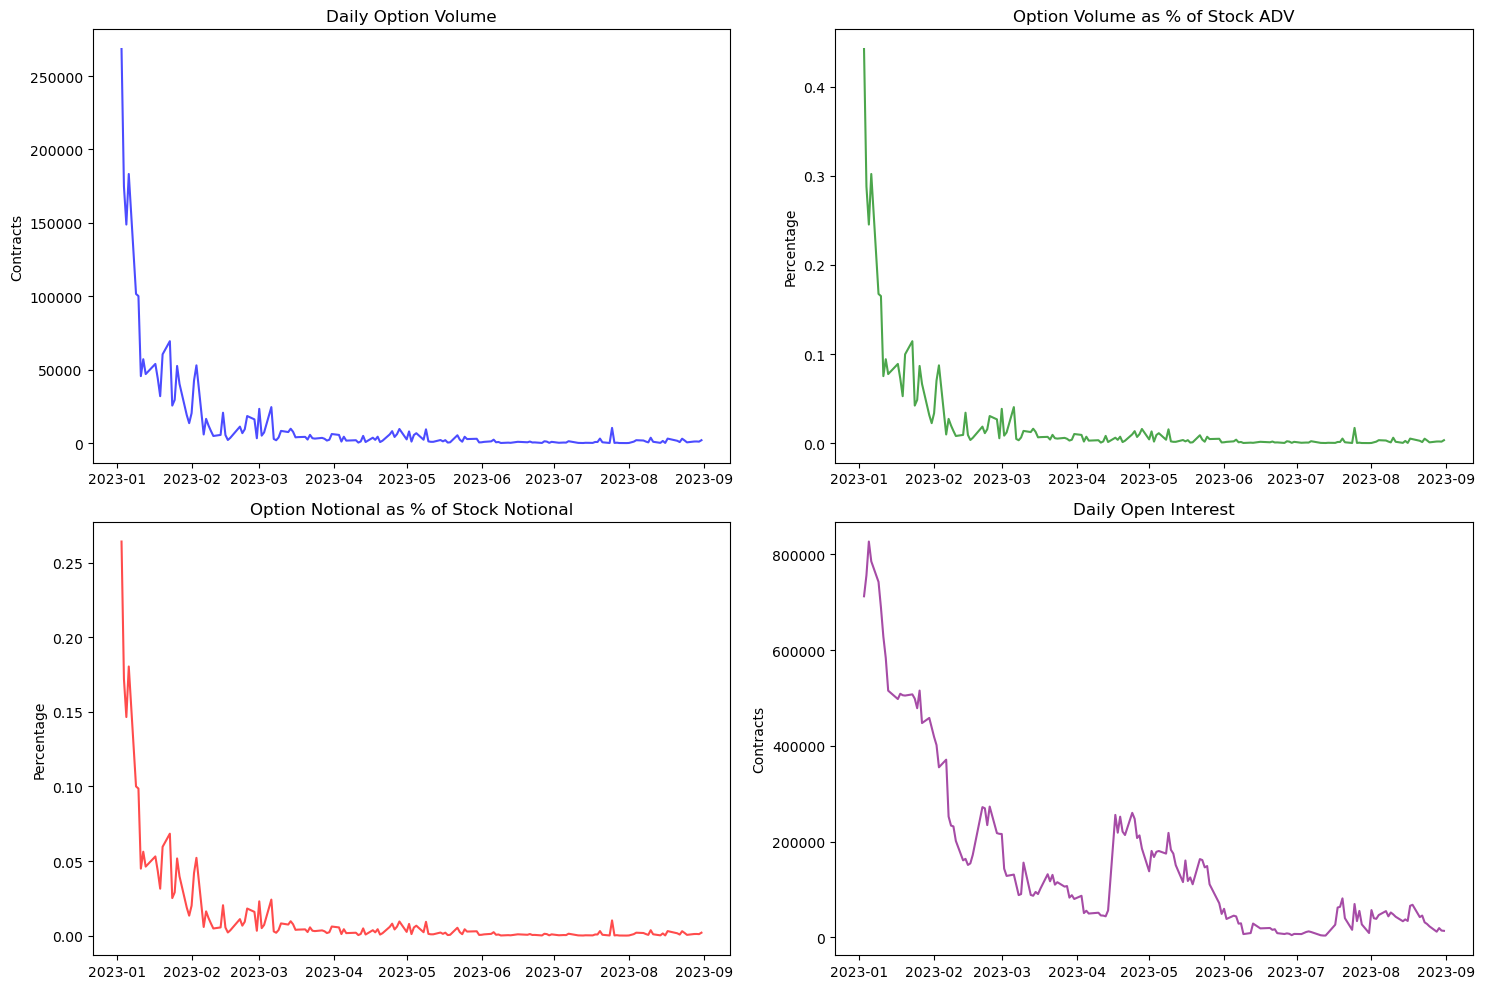


📊 Volume Analysis Summary:
Stock ADV: 60,686,220
Average Daily Option Volume: 13,283
Average Volume Ratio: 0.0%
Average Notional Ratio: 0.0%

📊 Volume Analysis Complete!


In [7]:
# Analyze option volume vs stock ADV
if 'options_filtered' in pipeline.data and 'stock_prices' in pipeline.data:
    volume_analysis = analyze_option_volume_vs_stock_adv(
        options_df=pipeline.data['options_filtered'],
        stock_df=pipeline.data['stock_prices'],
        ticker='AAPL'
    )
    
    if volume_analysis is not None:
        print("\n📊 Volume Analysis Complete!")

## 4. Regression Analysis (Meeting Requirement)

Build regression dataset and run kernel regression to predict post-earnings realized volatility.

In [8]:
# Build regression dataset
if 'earnings_options' in pipeline.data and 'realized_volatility' in pipeline.data:
    regression_data = build_regression_dataset(
        earnings_options_df=pipeline.data['earnings_options'],
        realized_vol_df=pipeline.data['realized_volatility'],
        target_window=21,  # 21-day realized volatility target
        feature_window=10  # 10-day feature window
    )
    
    if regression_data is not None and len(regression_data) > 10:
        # Prepare features and target
        feature_cols = ['avg_iv', 'iv_std', 'avg_volume', 'avg_spread', 'avg_tte', 'avg_moneyness']
        X = regression_data[feature_cols]
        y = regression_data['target_rv']
        
        print(f"\n🔬 Regression Dataset Summary:")
        print(f"Features: {feature_cols}")
        print(f"Target: 21-day realized volatility")
        print(f"Data points: {len(regression_data)}")
        
        # Run kernel regression
        regression_results = enhanced_kernel_regression_analysis(X, y)
        
        print(f"\n✅ Regression Analysis Complete!")
        print(f"Model performance: R² = {regression_results['test_r2']:.3f}")

## 5. Large Cap Universe (Meeting Requirement)

Build universe of large cap stocks with sufficient option volume for cross-sectional analysis.

In [9]:
# Get large cap universe
universe = get_large_cap_universe(
    pipeline=pipeline,
    min_market_cap=1e9,  # $1B+ market cap
    min_option_volume=1000  # 1000+ average daily option volume
)

if universe is not None:
    print(f"\n🏢 Large Cap Universe Summary:")
    print(f"Total stocks: {len(universe)}")
    print(f"Average market cap: ${universe['avg_market_cap'].mean()/1e9:.1f}B")
    print(f"Average option volume: {universe['avg_option_volume'].mean():.0f} contracts/day")
    
    # Show top stocks by market cap
    print(f"\n📈 Top 10 Stocks by Market Cap:")
    top_stocks = universe.nlargest(10, 'avg_market_cap')
    for _, stock in top_stocks.iterrows():
        print(f"{stock['ticker']}: ${stock['avg_market_cap']/1e9:.1f}B, {stock['avg_option_volume']:.0f} opt/day")

Building large cap universe with option volume filters...
Error building universe: (psycopg2.errors.UndefinedColumn) column s.share_vol does not exist
LINE 4:                p.close * s.share_vol as market_cap,
                                 ^

[SQL: 
    WITH market_caps AS (
        SELECT DISTINCT s.secid, s.ticker, s.issuer,
               p.close * s.share_vol as market_cap,
               p.date
        FROM optionm.securd1 s
        JOIN optionm.secprd p ON s.secid = p.secid
        WHERE s.exchange_d != 0
          AND p.date >= '2023-01-01'
          AND p.close * s.share_vol >= 1000000000.0
    ),
    option_volumes AS (
        SELECT secid, 
               AVG(COALESCE(volume, 0)) as avg_daily_volume,
               COUNT(*) as trading_days
        FROM optionm.opprcd2023
        WHERE volume IS NOT NULL AND volume > 0
        GROUP BY secid
        HAVING AVG(COALESCE(volume, 0)) >= 1000
    )
    SELECT DISTINCT m.secid, m.ticker, m.issuer, 
           AVG(m.market_cap)

KeyError: 'avg_market_cap'

## 6. Cross-Sectional Analysis (Meeting Requirement)

Run analysis across multiple stocks to get "things right on average, over many samples."

In [10]:
# Run analysis on multiple stocks (subset for demonstration)
if universe is not None:
    # Take top 5 stocks for demonstration
    demo_tickers = universe.head(5)['ticker'].tolist()
    
    print(f"\n🔬 Running Cross-Sectional Analysis on: {demo_tickers}")
    
    cross_sectional_results = []
    
    for ticker in demo_tickers:
        print(f"\n--- Analyzing {ticker} ---")
        try:
            case_study = run_single_name_case_study(
                pipeline=pipeline,
                ticker=ticker,
                start_date='2023-01-01',
                end_date='2024-12-31'
            )
            
            if case_study:
                cross_sectional_results.append({
                    'ticker': ticker,
                    'test_r2': case_study['regression_results']['test_r2'],
                    'test_rmse': case_study['regression_results']['test_rmse'],
                    'data_points': len(case_study['regression_data'])
                })
        except Exception as e:
            print(f"Error analyzing {ticker}: {e}")
    
    # Summary of cross-sectional results
    if cross_sectional_results:
        results_df = pd.DataFrame(cross_sectional_results)
        
        print(f"\n📊 Cross-Sectional Analysis Summary:")
        print(f"Average Test R²: {results_df['test_r2'].mean():.3f}")
        print(f"Average Test RMSE: {results_df['test_rmse'].mean():.4f}")
        print(f"Total data points: {results_df['data_points'].sum():,}")
        
        # Plot results
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        axes[0].bar(results_df['ticker'], results_df['test_r2'])
        axes[0].set_title('Test R² by Stock')
        axes[0].set_ylabel('R²')
        
        axes[1].bar(results_df['ticker'], results_df['test_rmse'])
        axes[1].set_title('Test RMSE by Stock')
        axes[1].set_ylabel('RMSE')
        
        plt.tight_layout()
        plt.show()


🔬 Running Cross-Sectional Analysis on: ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'META']

--- Analyzing AAPL ---

SINGLE-NAME CASE STUDY: AAPL
Fetching security information from OptionMetrics...
Retrieved 1 securities
Fetching earnings announcement dates from Compustat...
Retrieved 8 earnings announcements
Fetching stock prices from OptionMetrics...
Retrieved 167 stock price records
Fetching option data from OptionMetrics...
Executing options query...


KeyboardInterrupt: 

In [ ]:
# Close database connection
db.close()

print("\n🎉 Enhanced Analysis Complete!")
print("\nNext Steps (from meeting):")
print("1. Focus on specific maturity points and ATM moneyness")
print("2. Adjust realized volatility parameters based on 'eye-balling' the graphs")
print("3. Build robust but parsimonious initial regression model")
print("4. Decide between single-name vs cross-sectional approach")
print("5. Settle on universe of large cap stocks with option volume filters")